# Early Warning System for Risk-Off Detection — A Quant Strategy

**Bocconi / GSoM-PoliMI** · weekly Bloomberg dataset 2000-2021 (n=1107).
End-to-end orchestration of the pipeline already implemented in `src/`.
Heavy artifacts are **loaded** from `outputs/models/` and `outputs/tables/`
and existing figures are shown via `IPython.display.Image` so the whole
notebook runs end-to-end in under 5 minutes.

In [1]:
import os, sys, warnings
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ.setdefault('TF_ENABLE_ONEDNN_OPTS', '0')  # handoff par.5.3: deterministic AE
os.environ.setdefault('TF_DETERMINISTIC_OPS', '1')
warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np, pandas as pd
from IPython.display import Image, display, Markdown

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))
FIG = PROJECT_ROOT / 'reports' / 'figures'
TABLES = PROJECT_ROOT / 'outputs' / 'tables'
MODELS = PROJECT_ROOT / 'outputs' / 'models'
DATA = PROJECT_ROOT / 'data' / 'processed'
pd.set_option('display.width', 160)

## 1. Problem framing & business case
Severe risk-off weeks are rare but devastating — avoiding a handful of them
compounds into large CAGR/Sharpe wins. We build a **Quant Strategy** that runs
**1.5x equity** in calm regimes and rotates into a context-appropriate safe
haven (USD cash / Gold / MBS) when an early-warning signal fires. The framing
is **nowcasting**, not forecasting: detect stress at birth, not predict it.

## 2. Dataset & target Y
Bloomberg weekly export, 1111 obs Jan-2000 to Apr-2021, 43 features + binary
target Y (1 = risk-off). Risk-off prevalence **~21.3% overall**, concentrated
in 2000-02, 2008-09, 2010-12 and 2020; years 2013/2017/2019 have zero positives.

In [2]:
from src.data_loader import load_dataset
raw = load_dataset(verbose=False)
print('shape:', raw.shape, '| Y prevalence:', round(raw['Y'].mean(), 3))
by_year = raw['Y'].groupby(raw.index.year).agg(['sum','size','mean'])
by_year.tail(8).round(3)

shape: (1111, 43) | Y prevalence: 0.213


,sum,size,mean
Date,,,
2014,2,52,0.038
2015,6,52,0.115
2016,4,52,0.077
2017,0,52,0.000
2018,6,52,0.115
2019,0,53,0.000
2020,23,52,0.442
2021,0,16,0.000


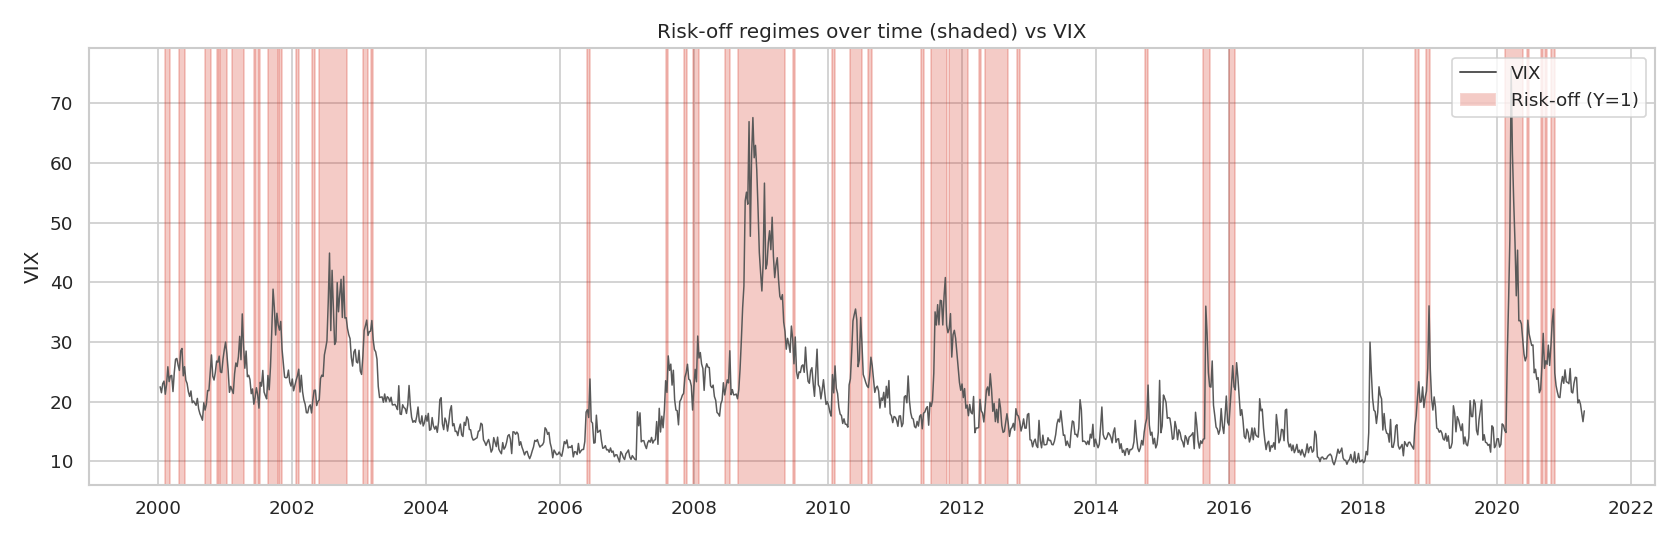

In [3]:
display(Image(filename=str(FIG/'y_timeline.png')))

## 3. Stationarity & transformations
Per-family transforms (`src/features.TRANSFORM_MAP`): log-returns for price
series (equities, FX, gold, oil, bond TR indices), first differences for
yields/rates, level for already-stationary series (VIX, ECSURPUS, Y).
All 43 features stationary at 5% by ADF after transformation.

In [4]:
from src.features import make_stationary, adf_table
stat = make_stationary(raw)
adf = adf_table(stat).head(6)
print('stationary shape:', stat.shape, '| all p<0.05?', bool((adf_table(stat).p_value < 0.05).all()))
adf.round(3)

stationary shape: (1110, 43) | all p<0.05? True


,transform,adf_stat,p_value,used_lag,n_obs,crit_1%,crit_5%,crit_10%,stationary
feature,,,,,,,,,
BDIY,log_return,-8.475,0.0,20,1089,-3.436,-2.864,-2.568,True
CRY,log_return,-10.024,0.0,7,1102,-3.436,-2.864,-2.568,True
Cl1,log_return,-13.715,0.0,4,1105,-3.436,-2.864,-2.568,True
DXY,log_return,-33.497,0.0,0,1109,-3.436,-2.864,-2.568,True
ECSURPUS,level,-6.481,0.0,7,1102,-3.436,-2.864,-2.568,True
EMUSTRUU,log_return,-16.530,0.0,2,1107,-3.436,-2.864,-2.568,True


## 4. Engineered spreads + collinearity cleanup
Eight cross-asset spreads (term, sovereign, credit-as-log-ratios), each with
level + 4w change, plus 4 standalone signals (equity-bond rotation, gold/oil
ratio, VRP, JPY strength). Pairs with |corr|>0.9 dropped (hy_spread, US
10Y-3M, GTGBP20Y, GTDEM30Y, USGG30YR): 56 cleaned features go into the models.

features clean: (1110, 40) | spreads clean: (1107, 16) | model panel = 56 + Y


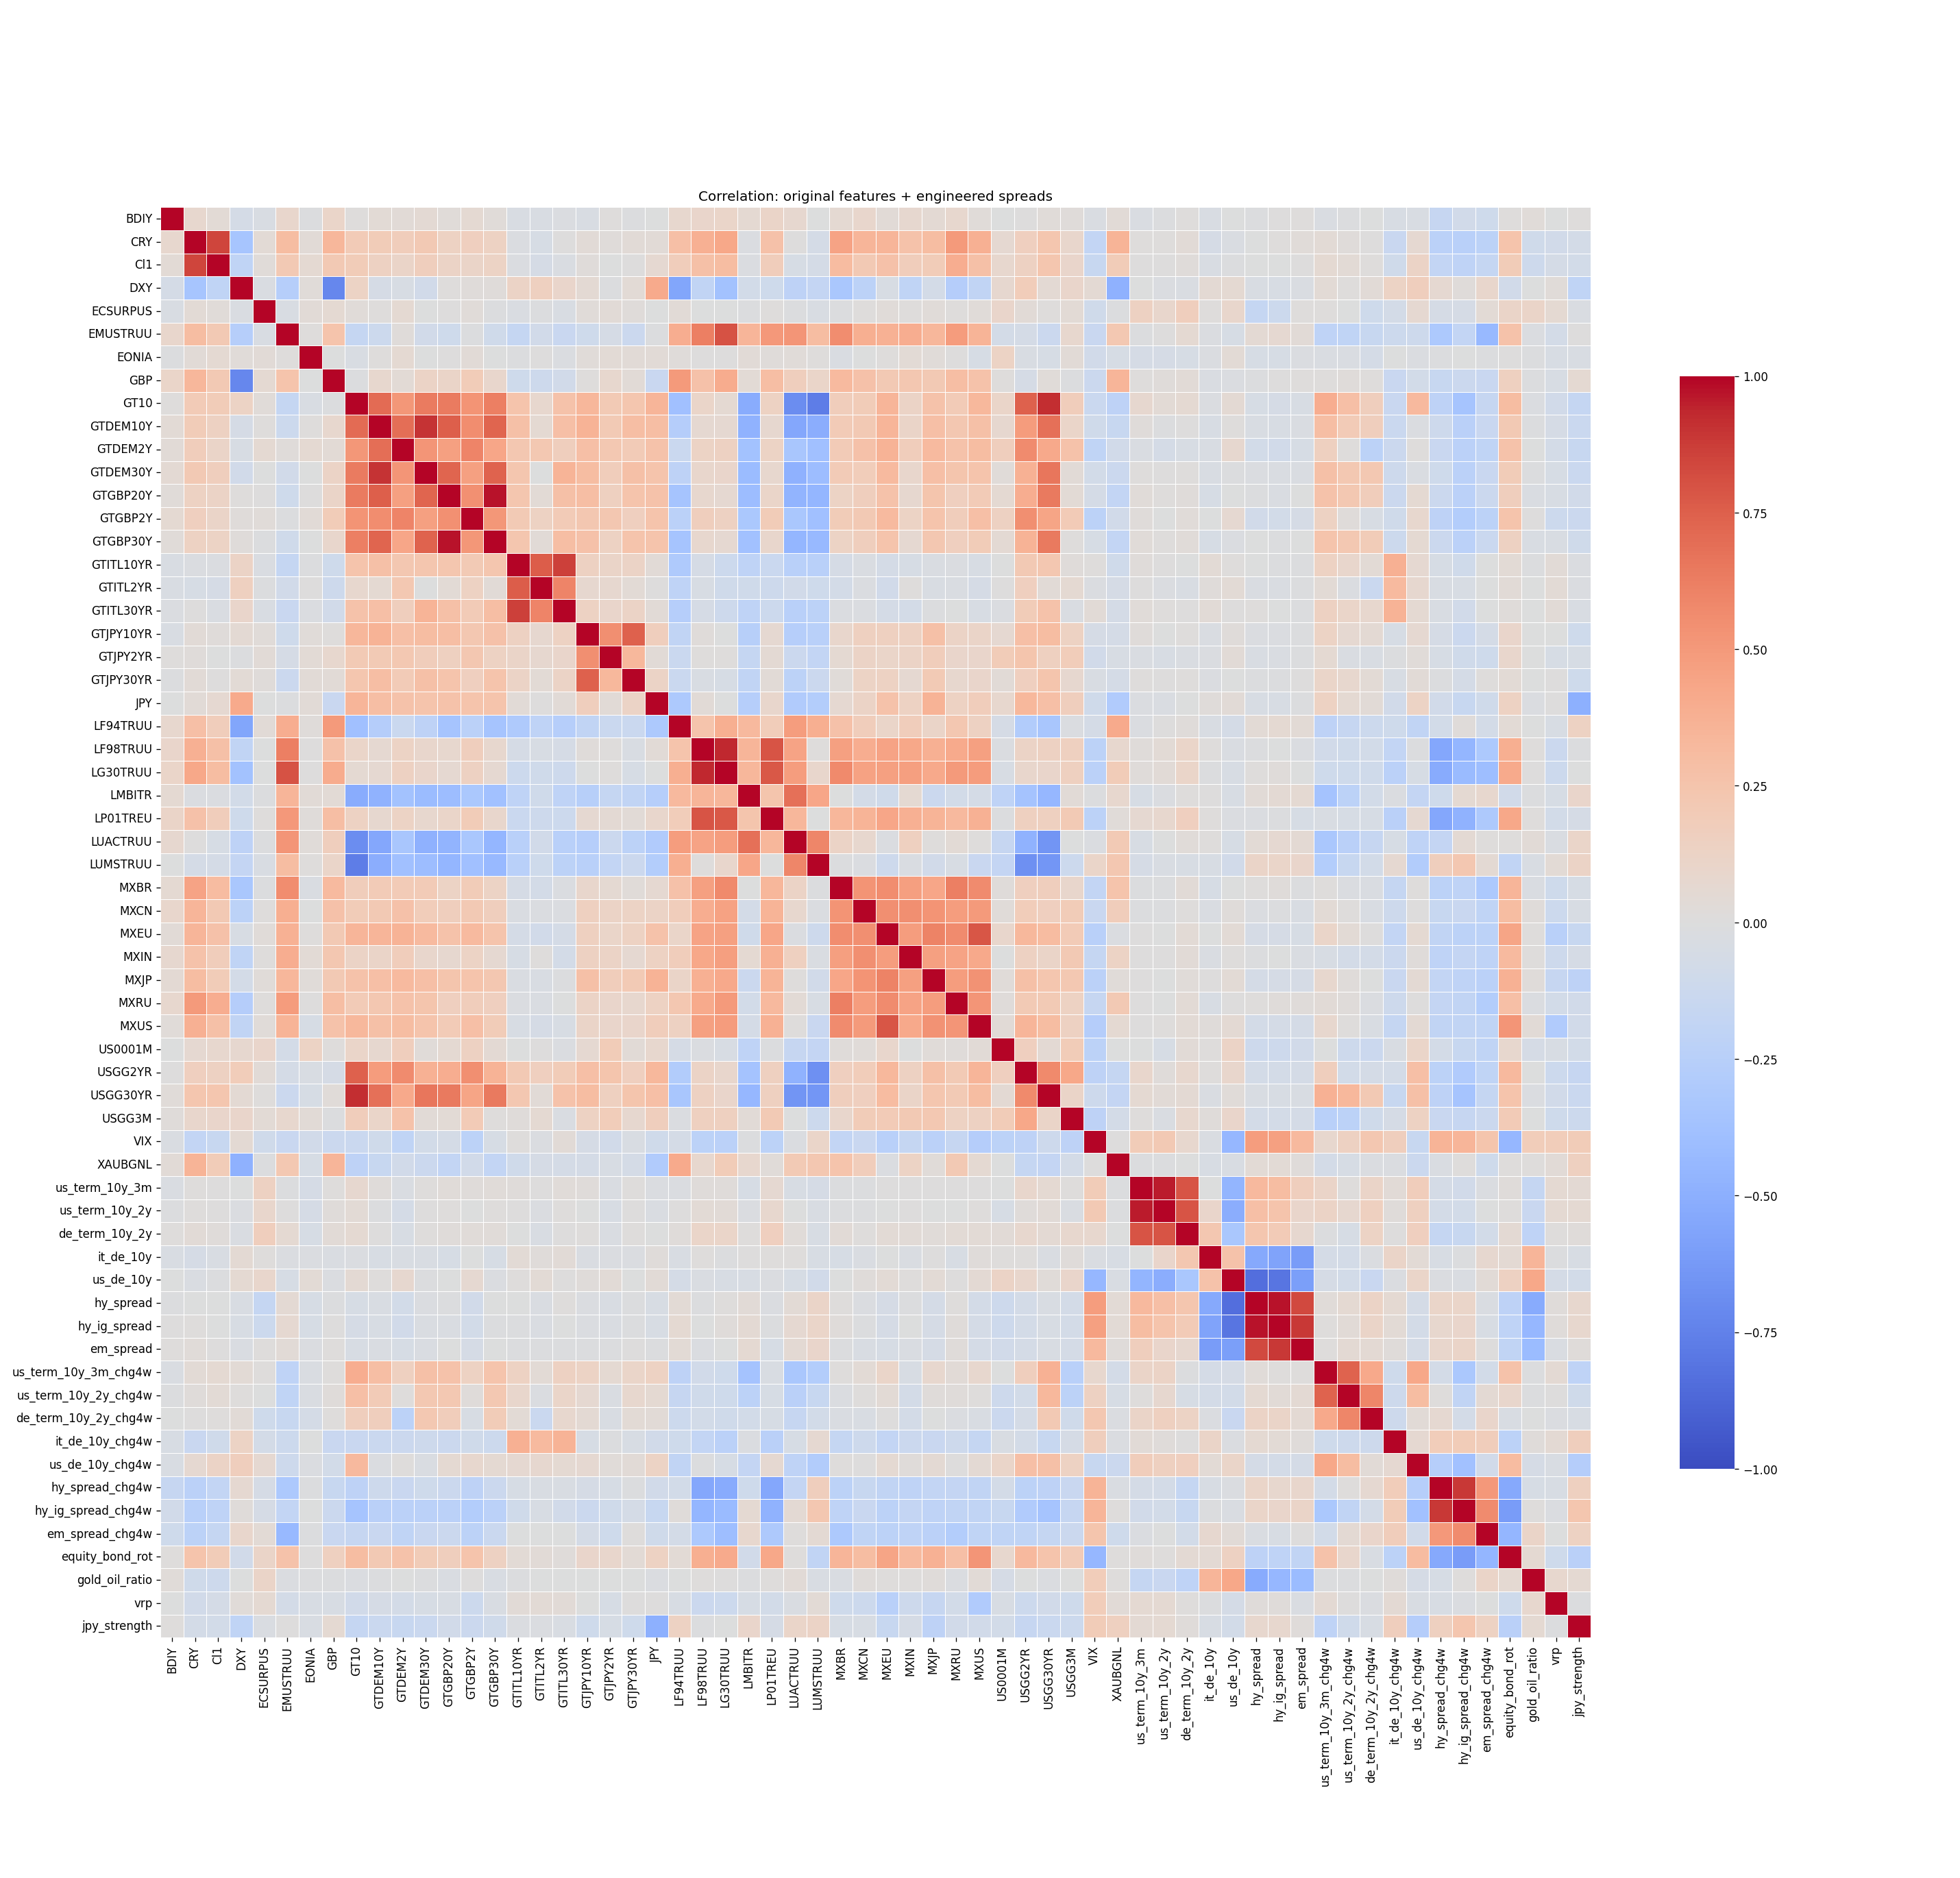

In [5]:
feat_clean = pd.read_parquet(DATA / 'features_stationary_clean.parquet')
spr_clean = pd.read_parquet(DATA / 'spreads_clean.parquet')
print('features clean:', feat_clean.shape, '| spreads clean:', spr_clean.shape,
      '| model panel = 56 + Y')
display(Image(filename=str(FIG/'feature_spread_correlation.png')))

## 5. Routing triggers (3 domains)
14 triggers grouped into **USD** (funding stress / haven), **Gold** (real
yields / fiat distrust) and **MBS** (rule-based carry filter). `dxy_chg4w` is
intentionally shared by USD and Gold with opposite economic readings.

triggers: (1060, 14)


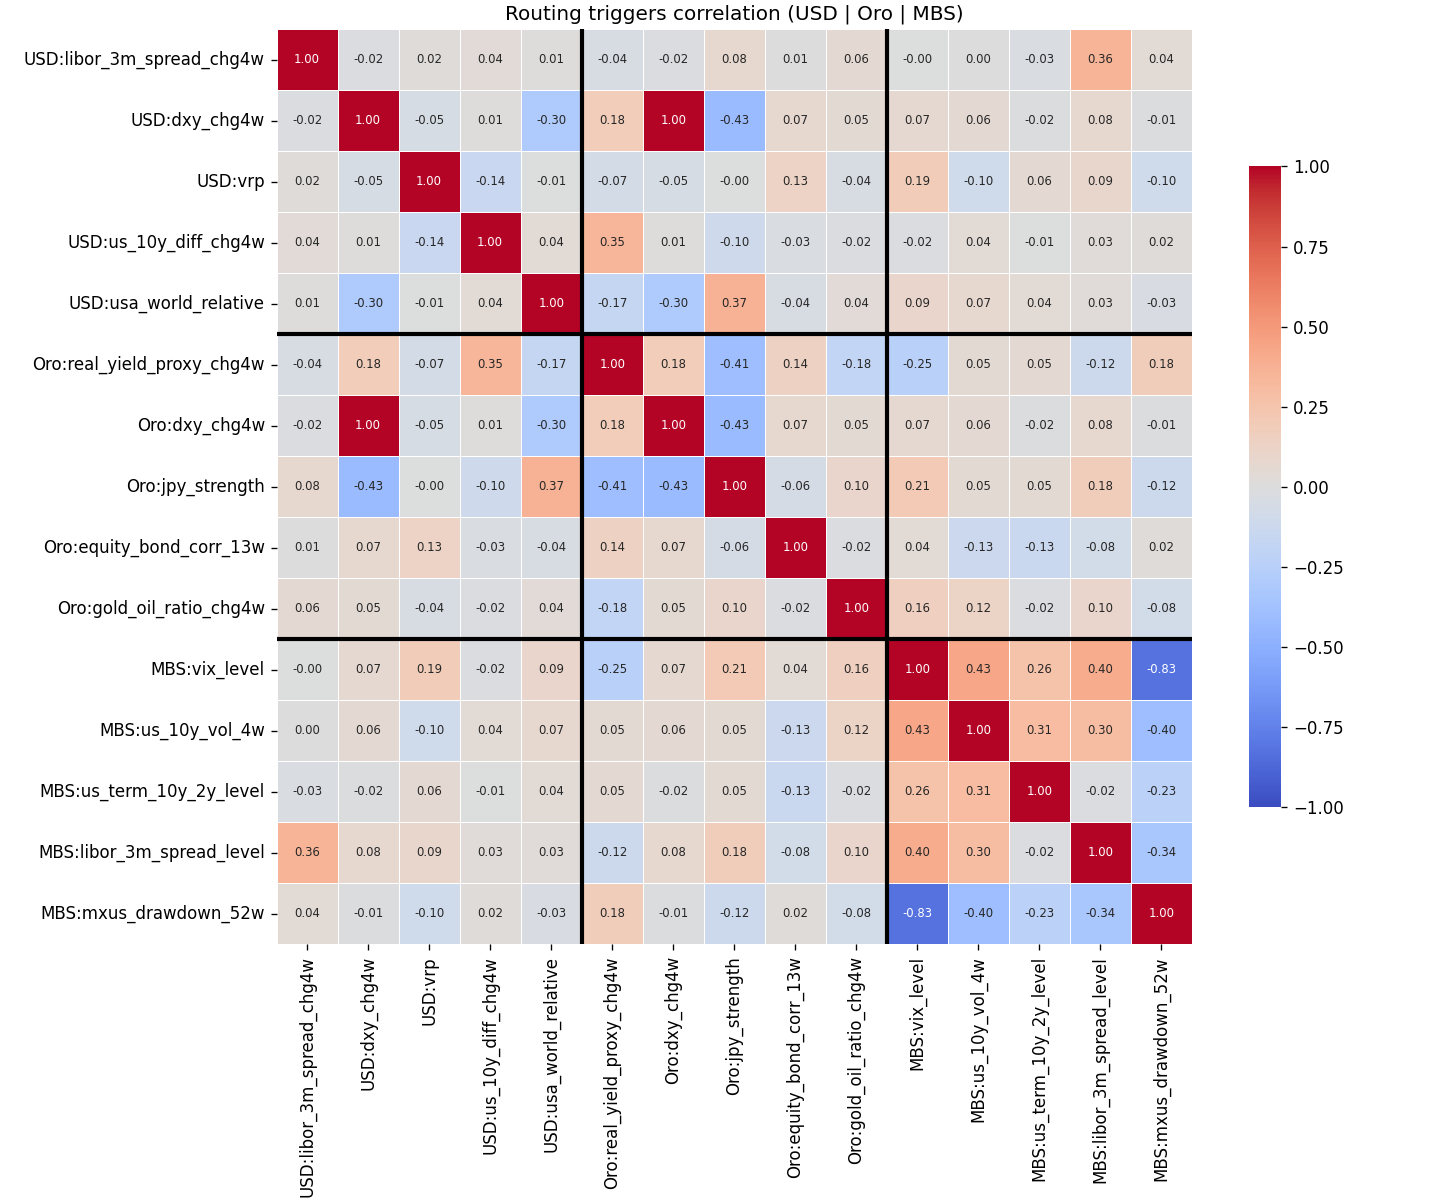

In [6]:
trig = pd.read_parquet(DATA / 'routing_triggers.parquet')
print('triggers:', trig.shape)
display(Image(filename=str(FIG/'routing_triggers_correlation.png')))

## 6. Walk-forward CV (5 folds + 4w embargo + sealed test holdout)
Development = up to 2018-12-31 (986 wks); sealed test = 2019-01 to 2021-04
(121 wks, contains COVID). Five expanding folds; 4-week embargo between
train end and val start kills 4w-lookback leakage. CV metrics are aggregated
**weighted by `n_pos`** — folds 1-2 dominate (GFC, euro), folds 3-5 are thin.

In [7]:
from src.splits import walkforward_split
wf = walkforward_split(save=False, verbose=False)
fold_summary = pd.DataFrame([{'fold': f['fold_id'],
                              'train_period': f"{f['train'].index.min().date()} -> {f['train'].index.max().date()}",
                              'val_period': f"{f['val'].index.min().date()} -> {f['val'].index.max().date()}",
                              'n_val': len(f['val']), 'n_pos': int(f['val']['Y'].sum()),
                              'crisis': f['crisis_captured']}
                             for f in wf['models']['cv_folds']])
fold_summary

,fold,train_period,val_period,n_val,n_pos,crisis
0,1,2000-02-08 -> 2006-12-26,2007-01-30 -> 2009-12-29,153,53,GFC 2008
1,2,2000-02-08 -> 2009-12-29,2010-02-02 -> 2012-12-25,152,64,Euro 2011
2,3,2000-02-08 -> 2012-12-25,2013-01-29 -> 2014-12-30,101,2,Taper 2013
3,4,2000-02-08 -> 2014-12-30,2015-02-03 -> 2016-12-27,100,10,China-Oil 2015-16
4,5,2000-02-08 -> 2016-12-27,2017-01-31 -> 2018-12-25,100,6,Q4 2018 selloff


## 7. MVG baseline (Ledoit-Wolf shrinkage)
Fit on Y=0 normals; score = squared Mahalanobis with shrunk precision (Sigma
is near-singular with 56 features and ~250 normals in Fold 1). Threshold
tuned via walk-forward, **n_pos-weighted median**.

In [8]:
mvg_csv = pd.read_csv(TABLES / 'mvg_walkforward.csv')
mvg_csv.round(3)

,fold_id,n_train,n_val,n_pos_val,epsilon_optimal,F1,Precision,Recall,AUC_ROC,AUC_PR,F_beta_2,note
0,1,313,153,53,81.741,0.596,0.424,1.000,0.826,0.823,0.786,Primary
1,2,470,152,64,68.894,0.618,0.448,1.000,0.809,0.800,0.802,Primary
2,3,626,101,2,73.880,0.077,0.042,0.500,0.631,0.043,0.156,"Noisy, n_pos=2"
3,4,731,100,10,141.723,0.294,0.208,0.500,0.682,0.209,0.391,"Caveat, n_pos=10"
4,5,835,100,6,97.310,0.500,0.500,0.500,0.918,0.350,0.500,"Noisy, n_pos=6"
5,weighted_mean,2975,606,135,81.741,0.572,0.417,0.933,0.808,0.734,0.742,n_pos-weighted (median eps)
6,test_holdout,744,121,23,81.741,0.635,0.500,0.870,0.883,0.764,0.758,final eval (COVID)


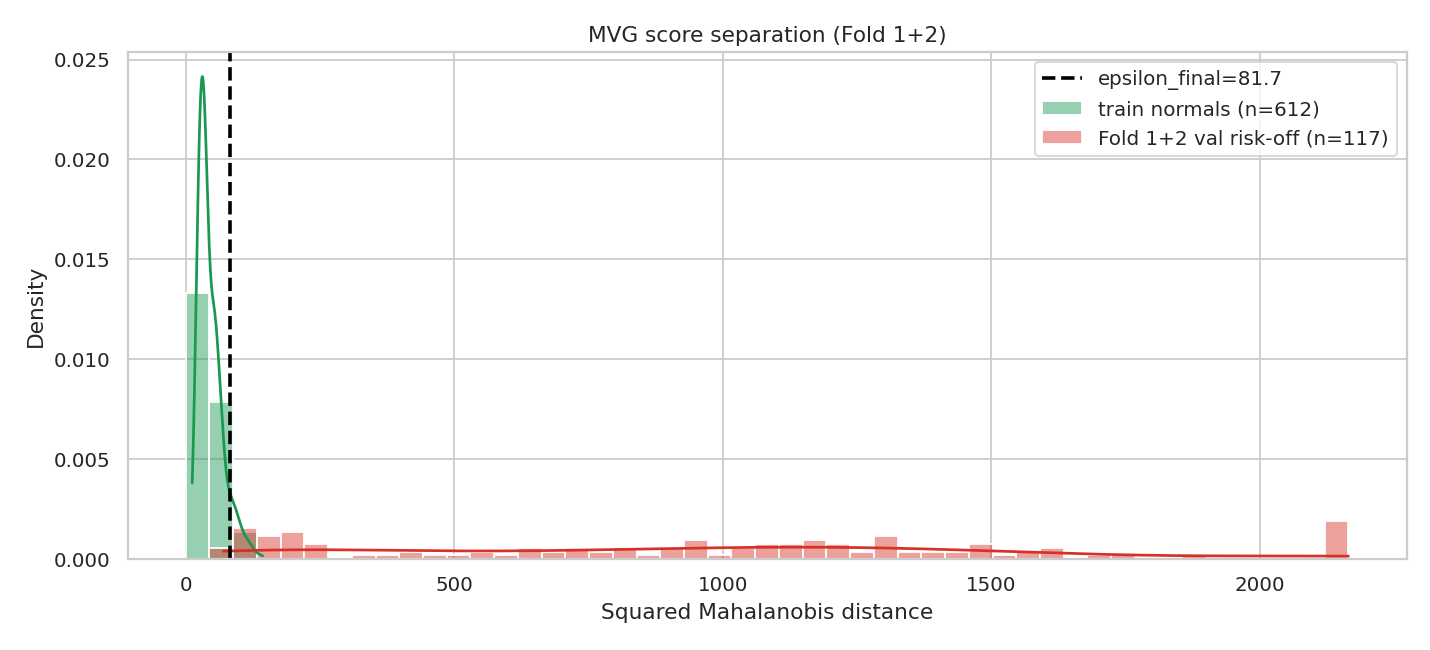

In [9]:
display(Image(filename=str(FIG/'mvg_score_distribution.png')))

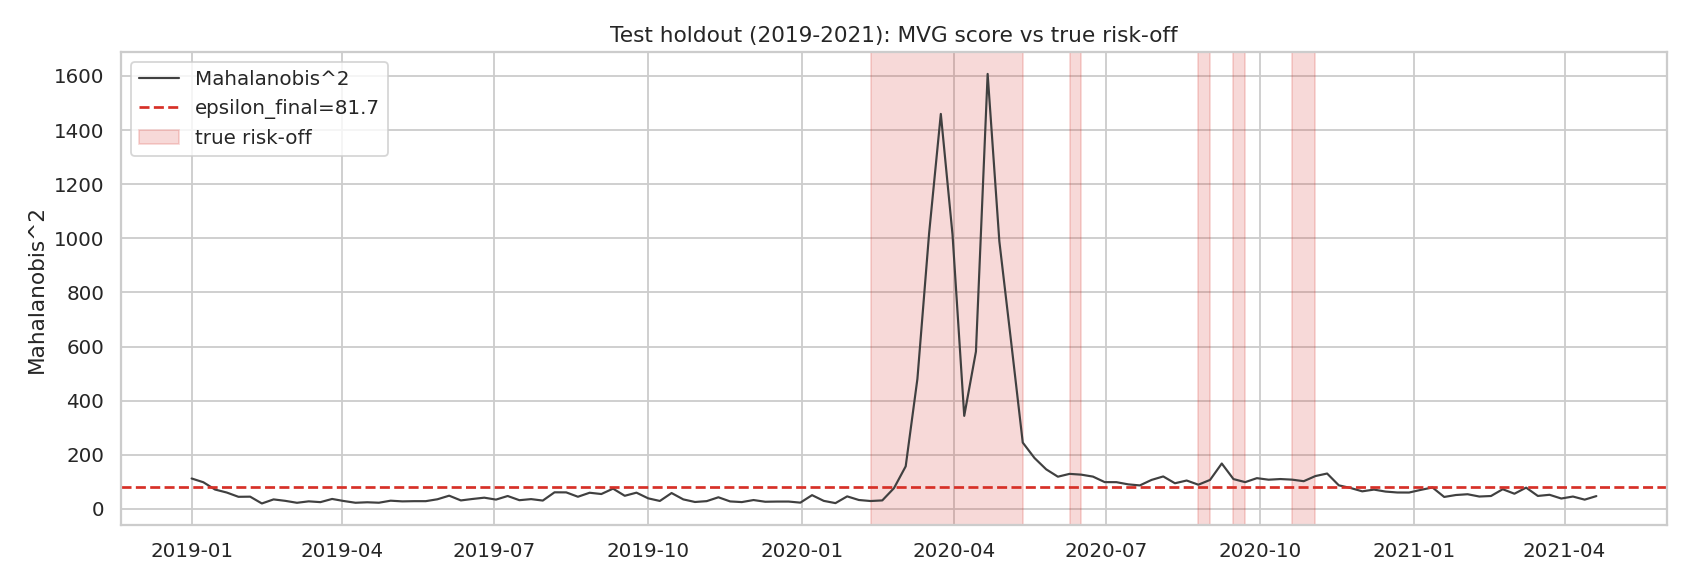

In [10]:
display(Image(filename=str(FIG/'mvg_test_timeline.png')))

## 8. SVM + Autoencoder + Isolation Forest
Three more novelty detectors with the MVG interface: One-Class SVM (RBF,
grid `nu x gamma`), Autoencoder (56-24-12-6-12-24-56, dropout 0.15, internal
early-stopping on the train), Isolation Forest (contamination as operating
point since score is contamination-invariant). All clear F1>0.40 and AUC-PR>0.65.

In [11]:
cmp = pd.read_csv(TABLES / 'models_comparison.csv')
cmp.round(3)

,model,F1_weighted_CV,AUC-PR_weighted_CV,AUC-ROC_weighted_CV,F1_test,AUC-PR_test,AUC-ROC_test,F-beta_2_test,hyperparams_optimi
0,MVG,0.572,0.734,0.808,0.635,0.764,0.883,0.758,ledoit-wolf
1,SVM,0.649,0.729,0.814,0.605,0.738,0.853,0.580,"nu=0.1, gamma=0.001"
2,AE,0.617,0.718,0.800,0.588,0.778,0.876,0.485,"arch 56-24-12-6-12-24-56, dropout 0.15"
3,IF,0.576,0.652,0.752,0.571,0.671,0.806,0.541,"contamination=0.1, n_est=200"


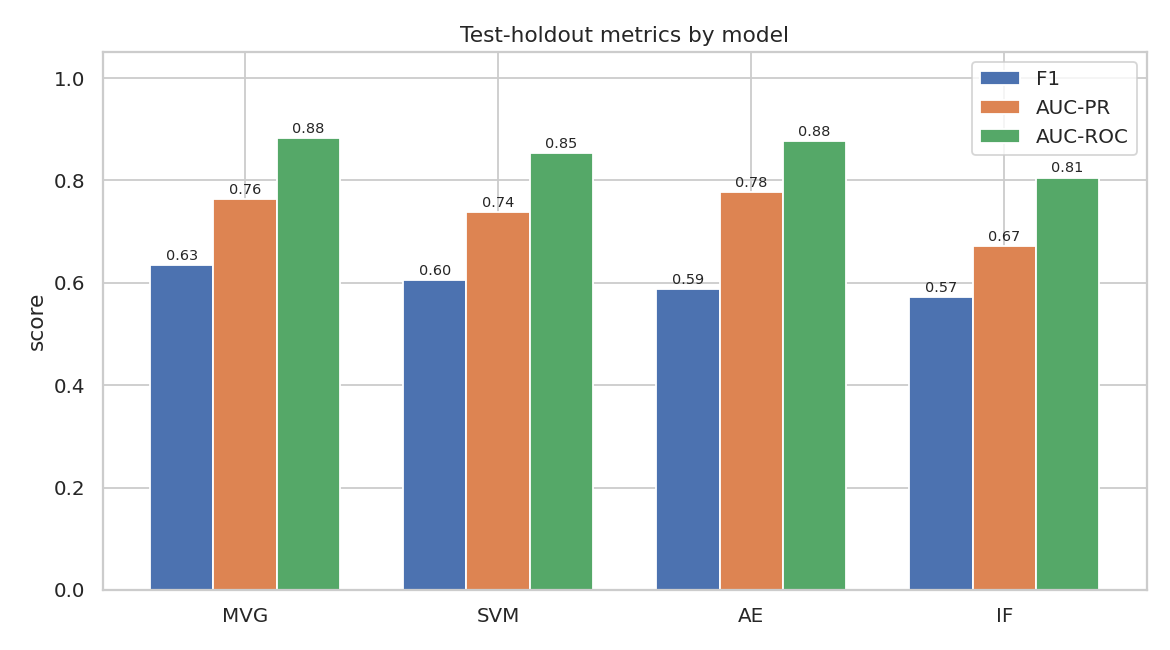

In [12]:
display(Image(filename=str(FIG/'models_comparison_metrics.png')))

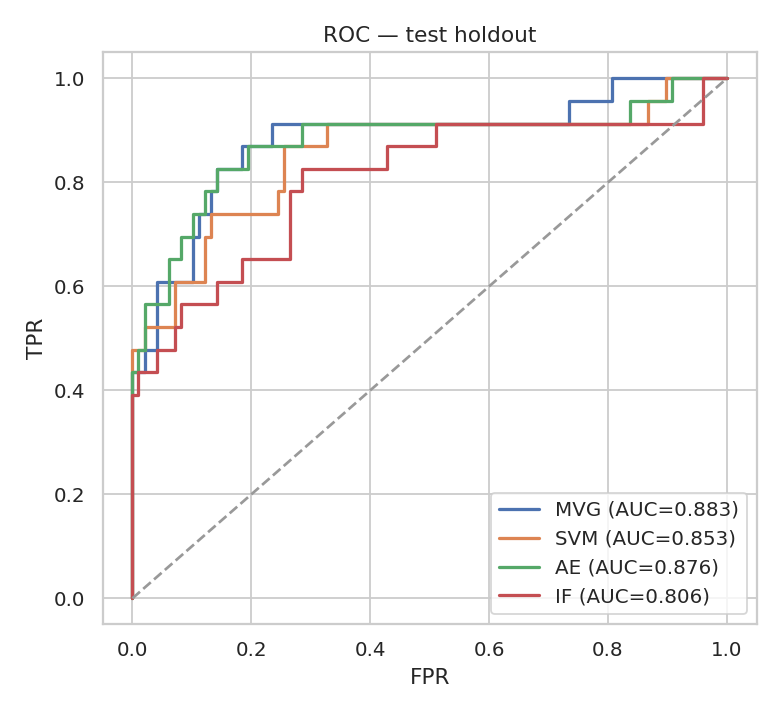

In [13]:
display(Image(filename=str(FIG/'models_test_roc_curves.png')))

## 9. Ensemble + error-correlation analysis
Map raw scores to **empirical percentiles** vs train-normals, then aggregate
(hard >=3/4 vote, soft mean, soft median). Soft-median wins test F1 (**0.647**
vs MVG 0.635) — a small win. Mean pairwise **error correlation = 0.507**:
models share the same feature space, so the boost is modest. Honest finding
we list as a limitation.

In [14]:
ens = pd.read_csv(TABLES / 'ensemble_comparison.csv')
ens.round(3)

,model_name,F1_wCV,AUC_PR_wCV,AUC_ROC_wCV,F1_test,AUC_PR_test,AUC_ROC_test,F_beta_2_test
0,MVG,0.572,0.734,0.808,0.635,0.764,0.883,0.758
1,SVM,0.649,0.729,0.814,0.605,0.738,0.853,0.580
2,AE,0.617,0.718,0.800,0.588,0.778,0.876,0.485
3,IF,0.576,0.652,0.752,0.571,0.671,0.806,0.541
4,ENS_hard,0.593,0.531,0.740,0.615,0.663,0.886,0.556
5,ENS_soft_mean,0.655,0.670,0.784,0.634,0.742,0.858,0.591
6,ENS_soft_median,0.650,0.606,0.776,0.647,0.753,0.860,0.534


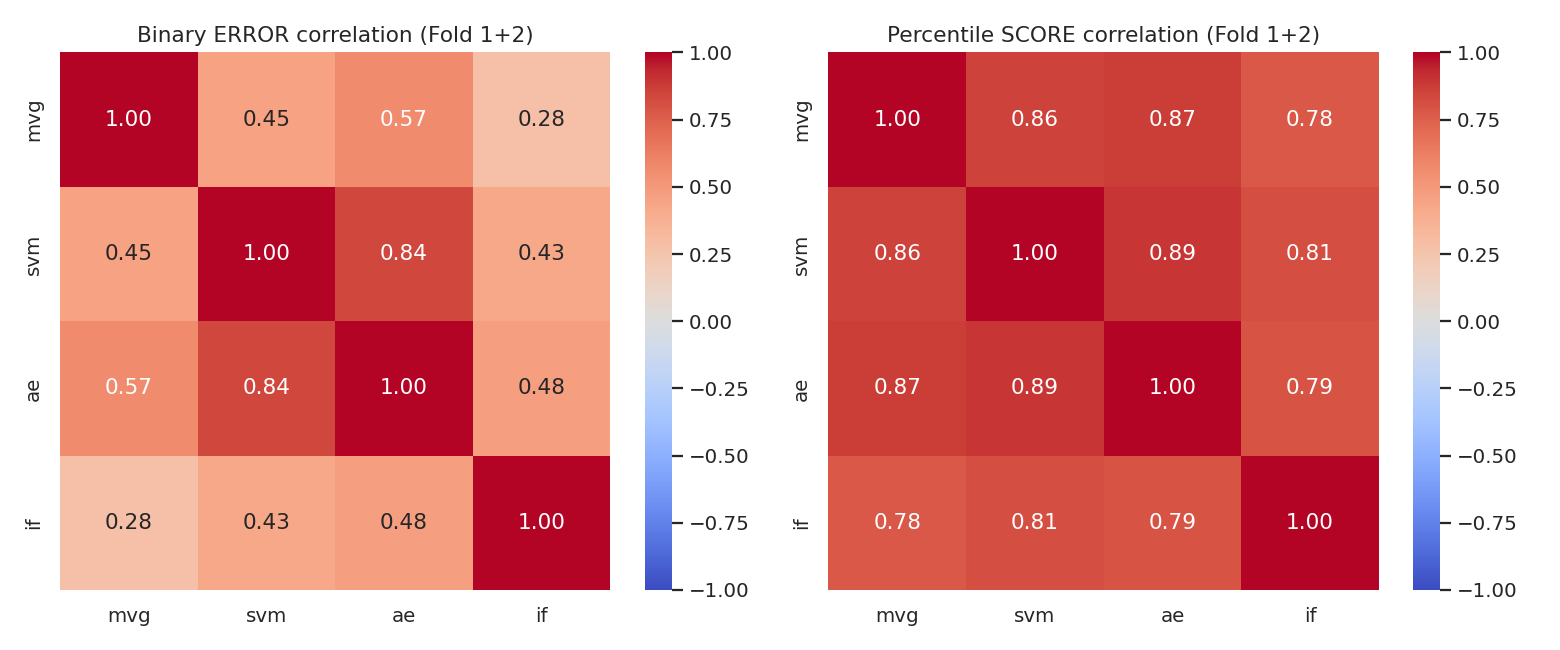

In [15]:
display(Image(filename=str(FIG/'ensemble_errors_correlation.png')))

## 10. Domain sub-scores (USD / Gold / MBS)
Mean of *signed z-scores* for USD and Gold (mu/sigma fit on development
ONLY). MBS is a binary rule: active in moderate stress (VIX 20-28, positive
term spread, mild equity drawdown) and **blocked** in acute crises
(VIX>30, LIBOR>p90_dev, fast HY-IG widening).

In [16]:
sub = pd.read_parquet(DATA / 'subscores' / 'test_holdout.parquet')
print('test subscores stats:'); sub.describe().round(3)

test subscores stats:


,date_index,subscore_usd,subscore_oro,subscore_mbs
count,121,121.000,121.000,121.000
mean,2020-02-25 00:00:00,0.089,0.140,0.025
min,2019-01-01 00:00:00,-1.123,-11.824,0.000
25%,2019-07-30 00:00:00,-0.085,-0.424,0.000
50%,2020-02-25 00:00:00,0.111,0.006,0.000
75%,2020-09-22 00:00:00,0.317,0.480,0.000
max,2021-04-20 00:00:00,1.448,11.918,1.000
std,NaN,0.369,2.126,0.156


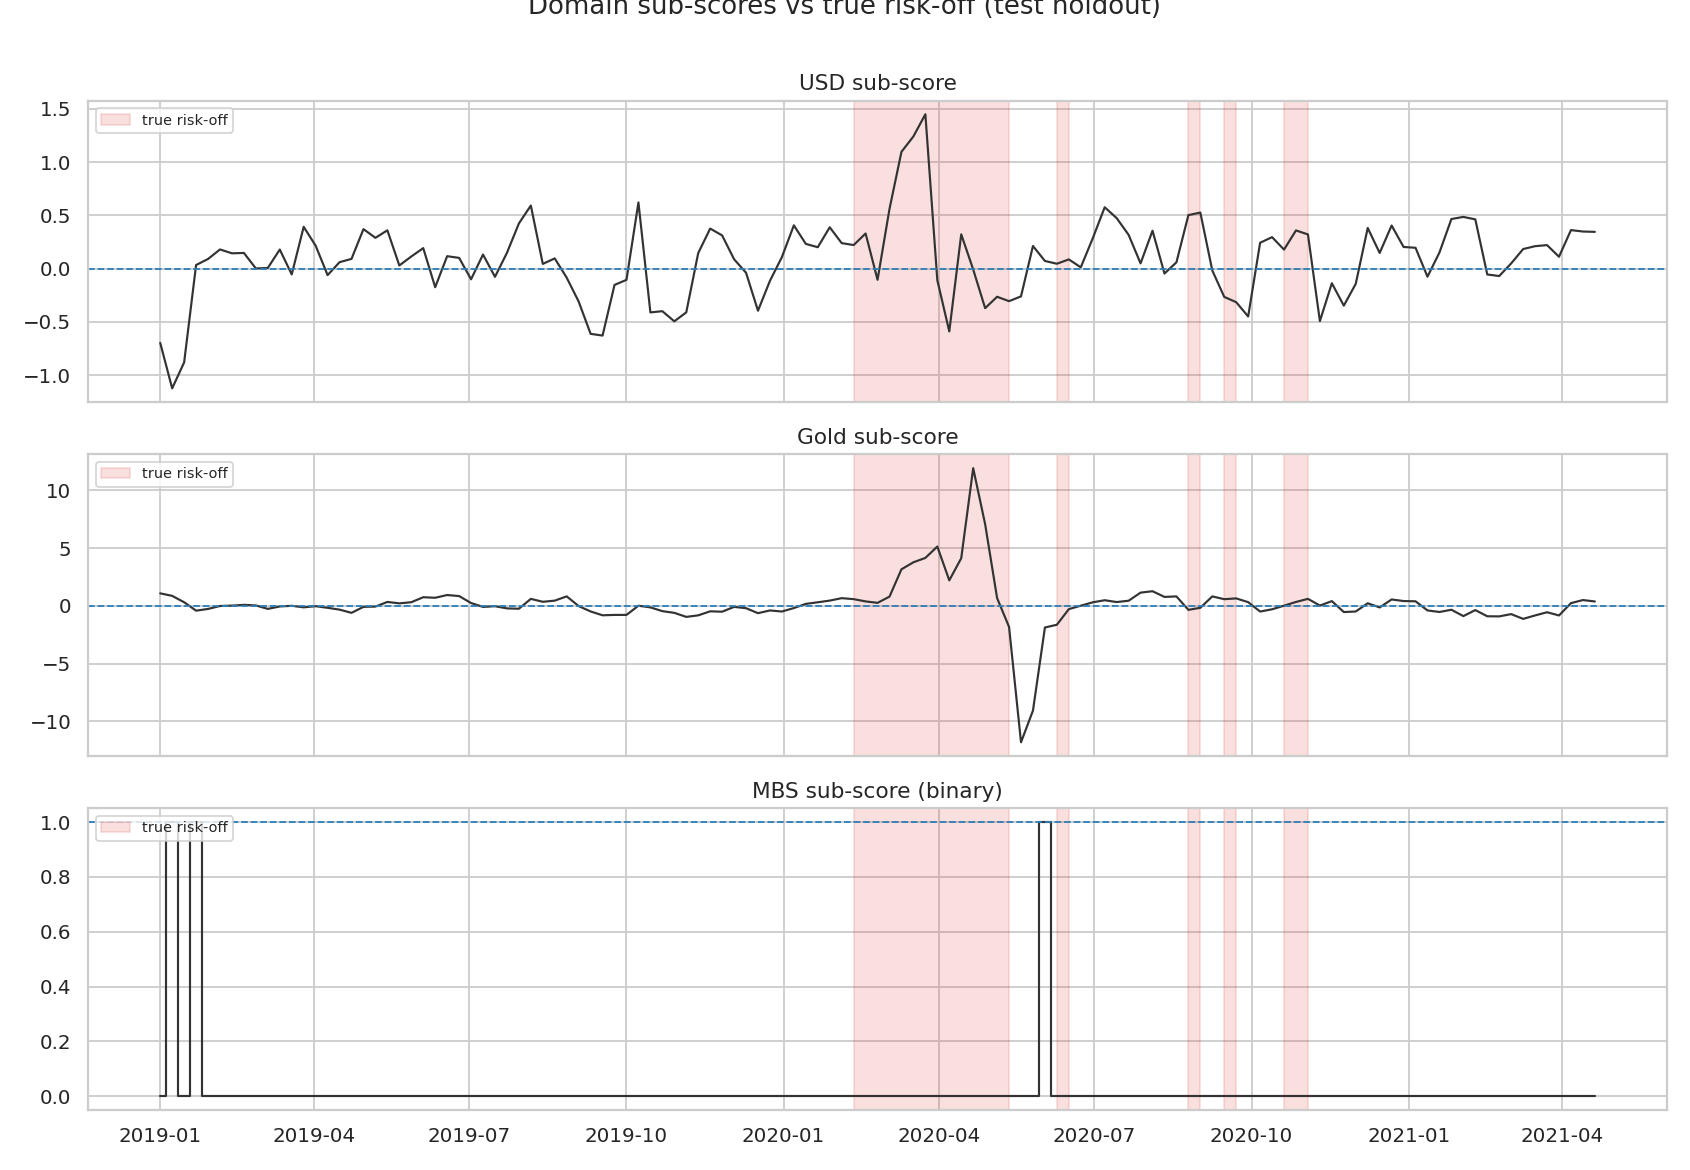

In [17]:
display(Image(filename=str(FIG/'subscores_test_timeline.png')))

## 11. Routing engine + decision matrix
If the ensemble says risk-on -> 1.5x levered equity. Otherwise pick the
haven: USD cash if `sub_usd > th_usd AND dxy_chg4w>0`, else Gold if
`sub_oro > th_oro`, else MBS if active, else default to USD cash.

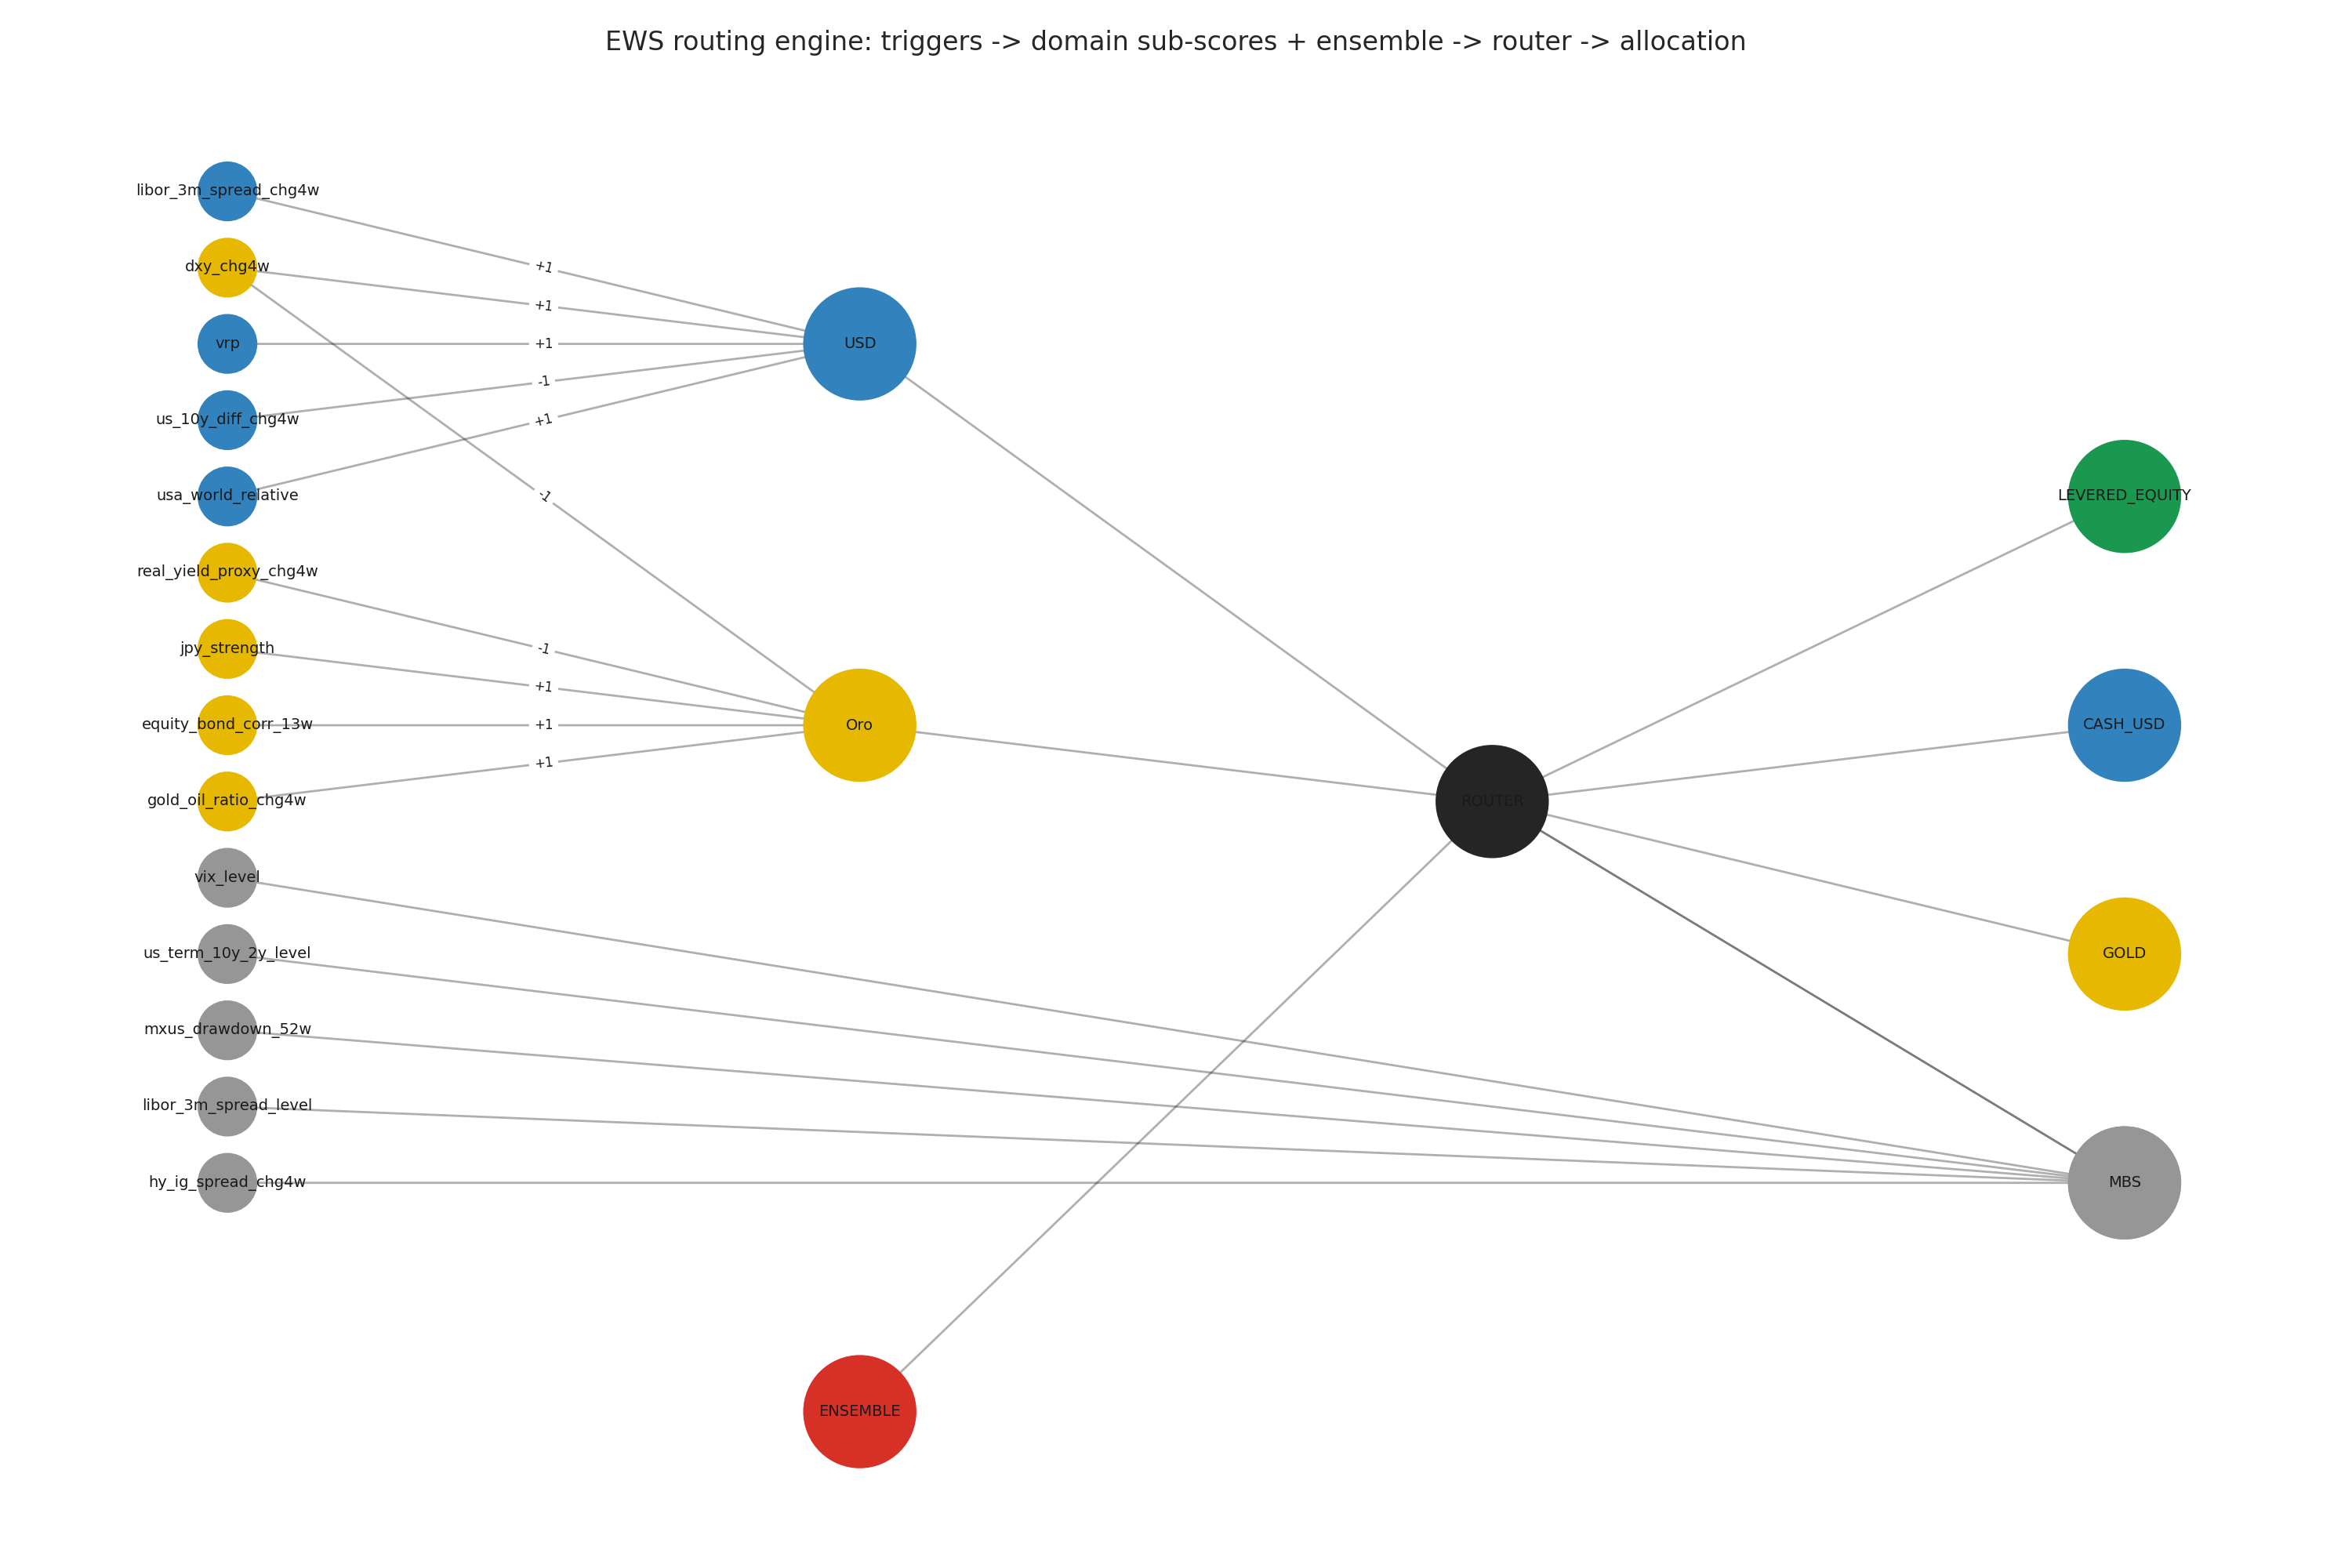

In [18]:
display(Image(filename=str(FIG/'routing_network.png')))

## 12. Backtest vs 5 benchmarks + threshold optimization
Calmar grid (`usd x oro`, 5x5) optimized on fold vals with duration-weighted
median Calmar -> **best (usd=1.5, oro=0.5)**. Benchmarks: MSCI BH, 60/40,
Butterfly, Permanent, Risk Parity. Weekly TC (bps one-way): equity=5, bond=5,
gold=8, cash=2, mbs=20. Weights lagged 1 week (no look-ahead).

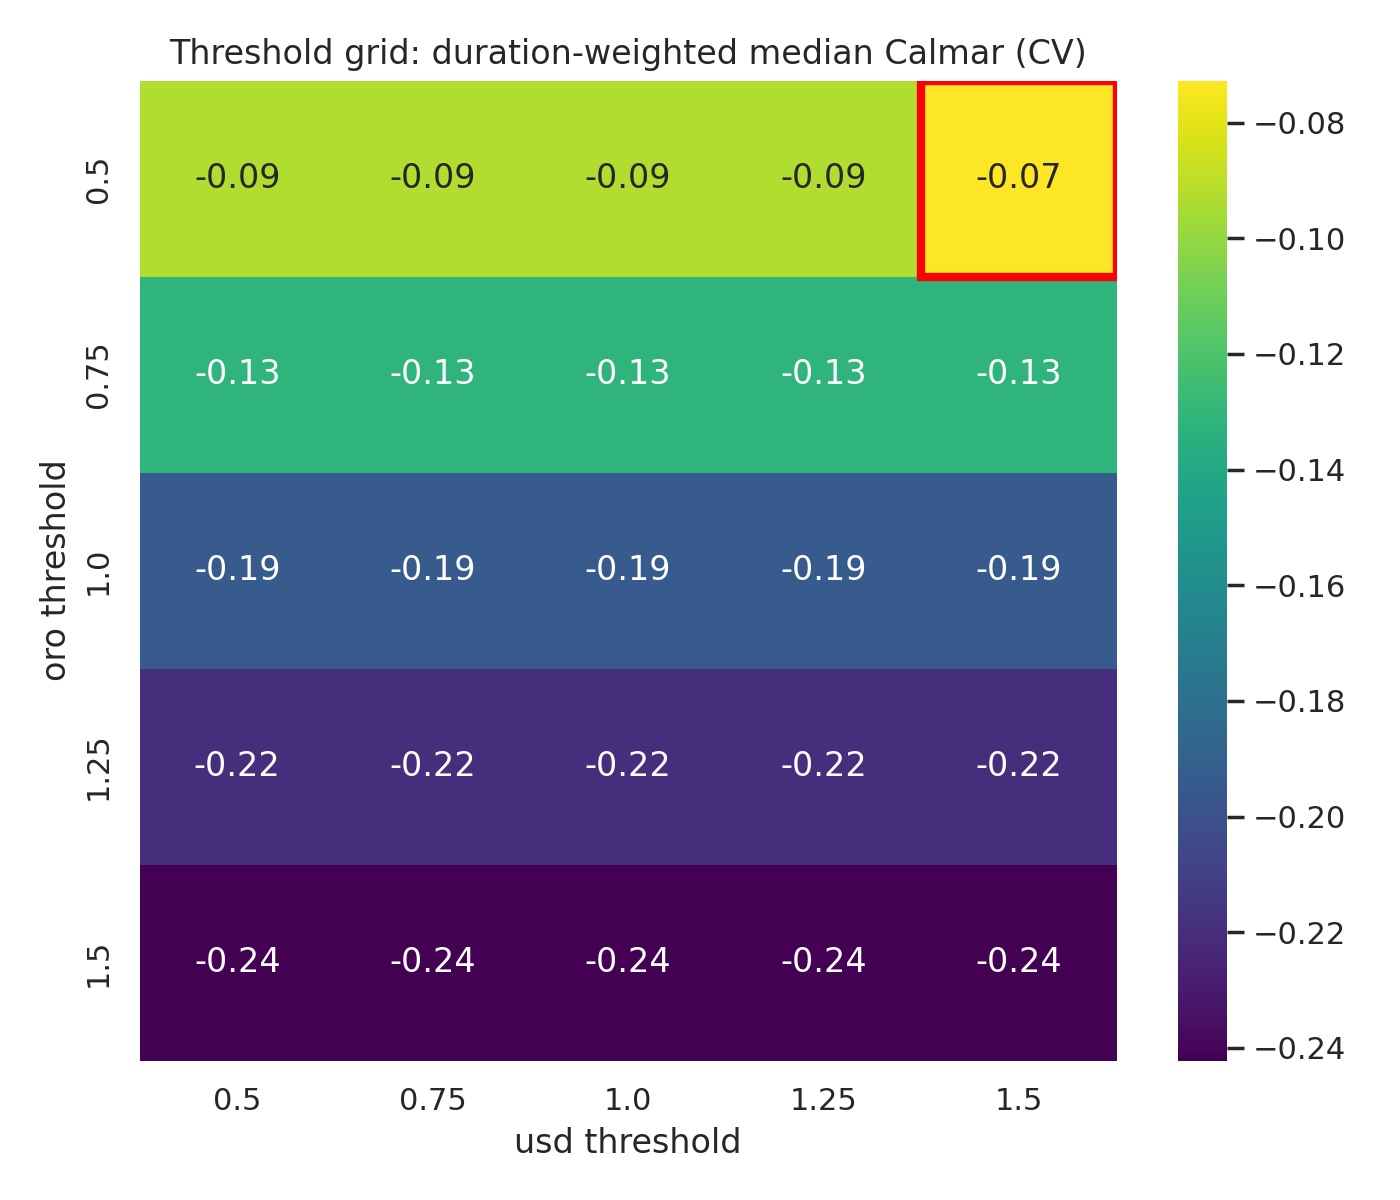

In [19]:
display(Image(filename=str(FIG/'threshold_heatmap.png')))

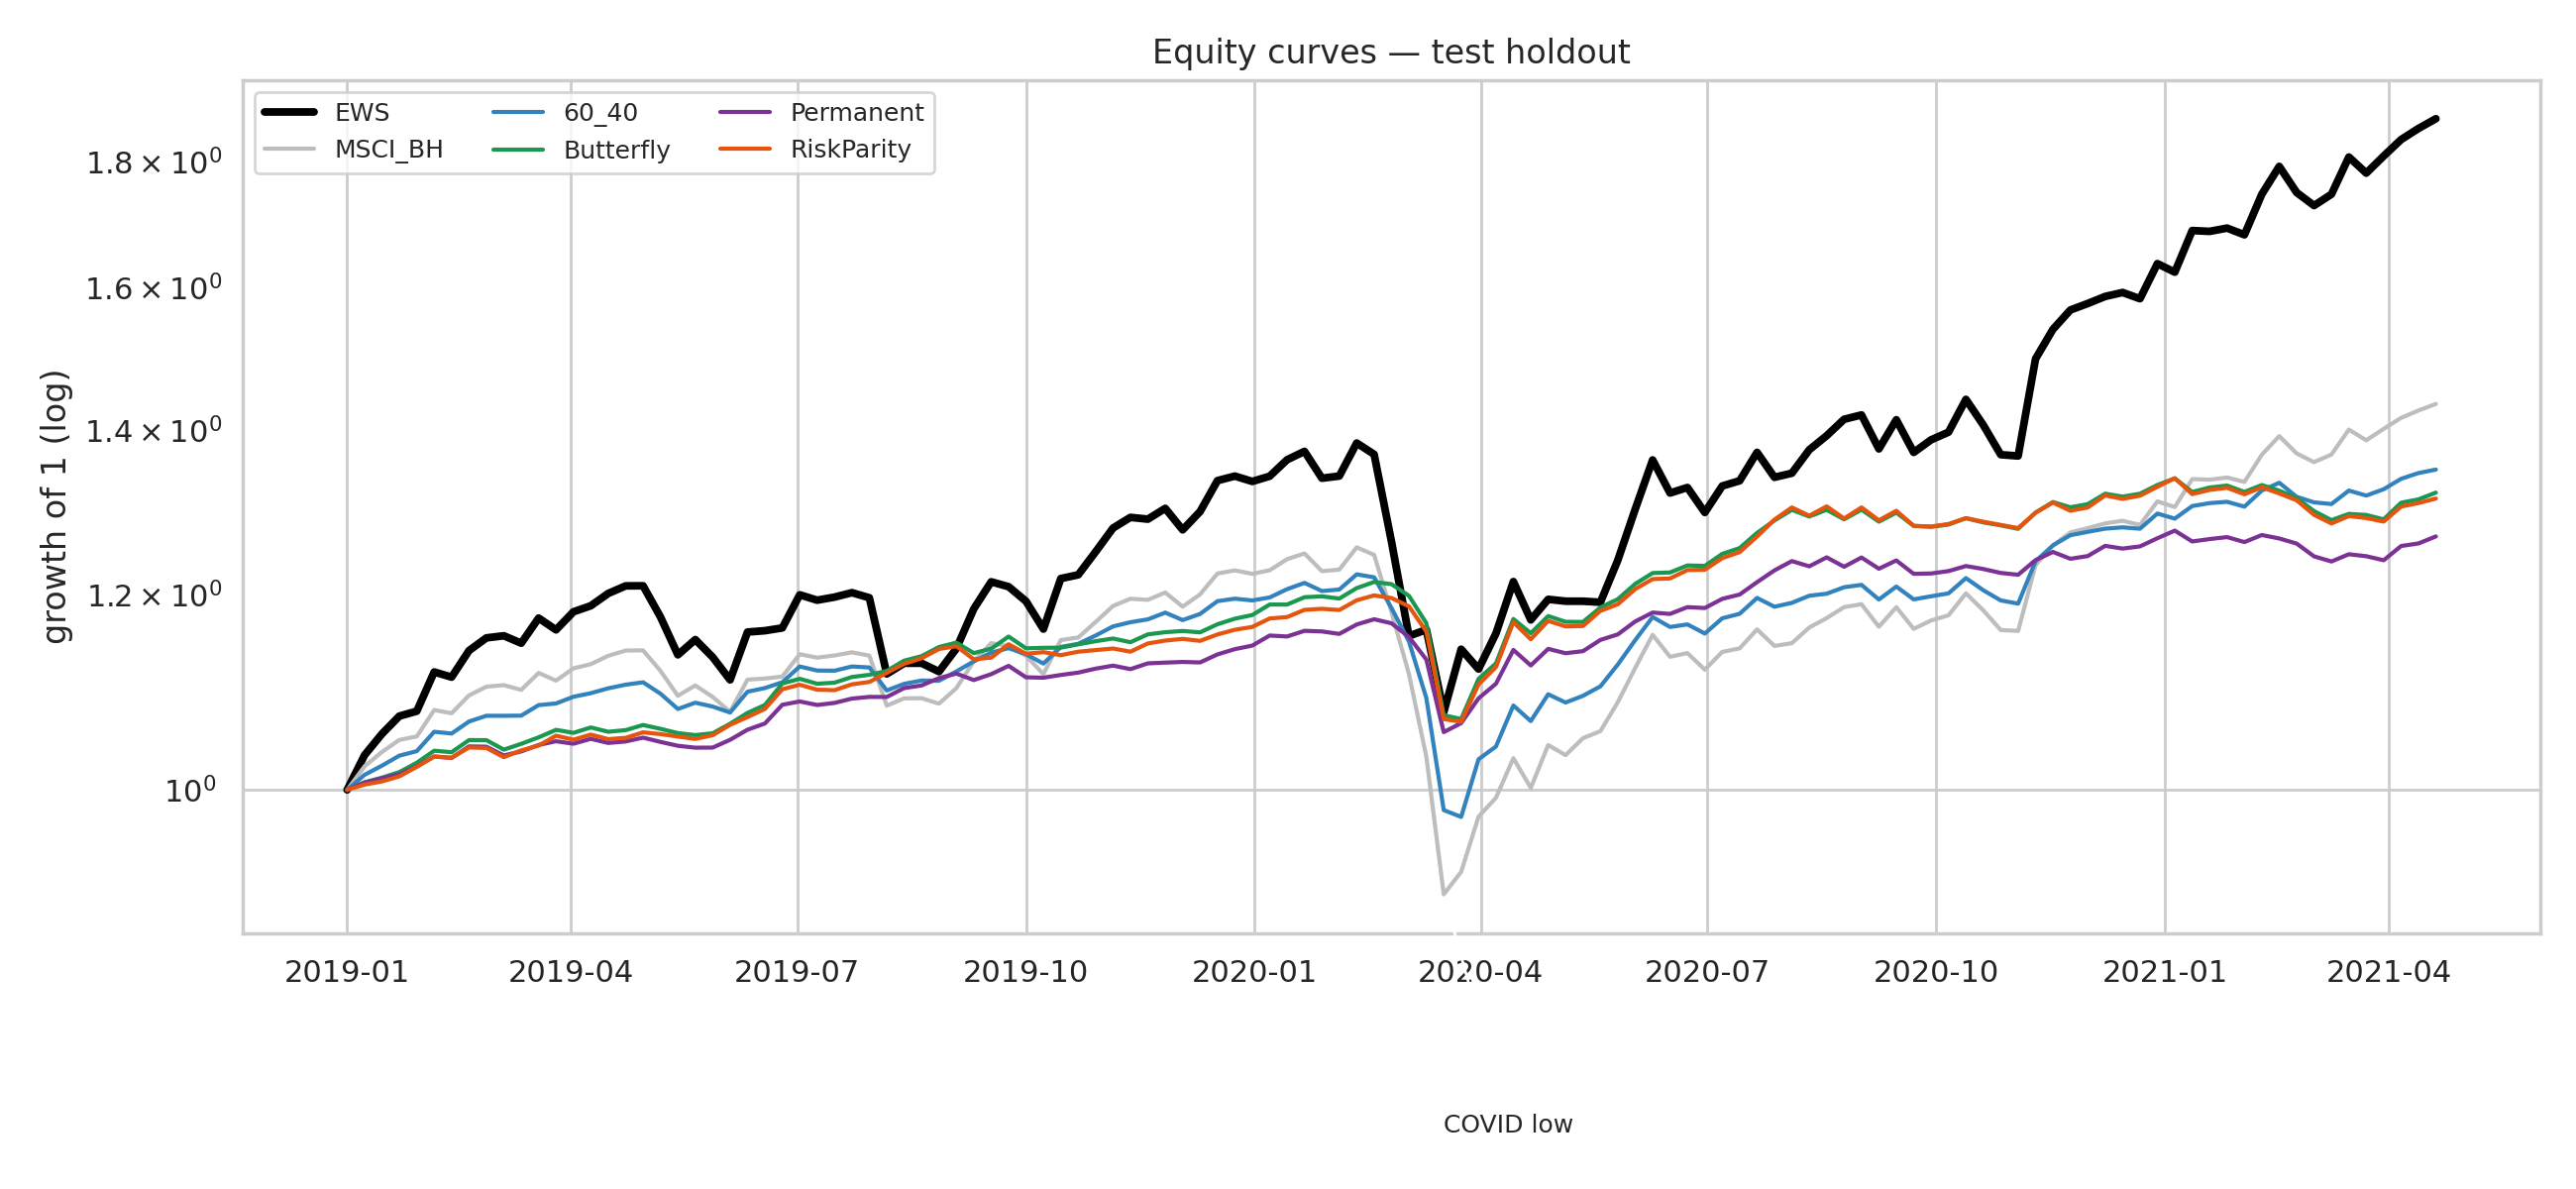

In [20]:
display(Image(filename=str(FIG/'equity_curves_all.png')))

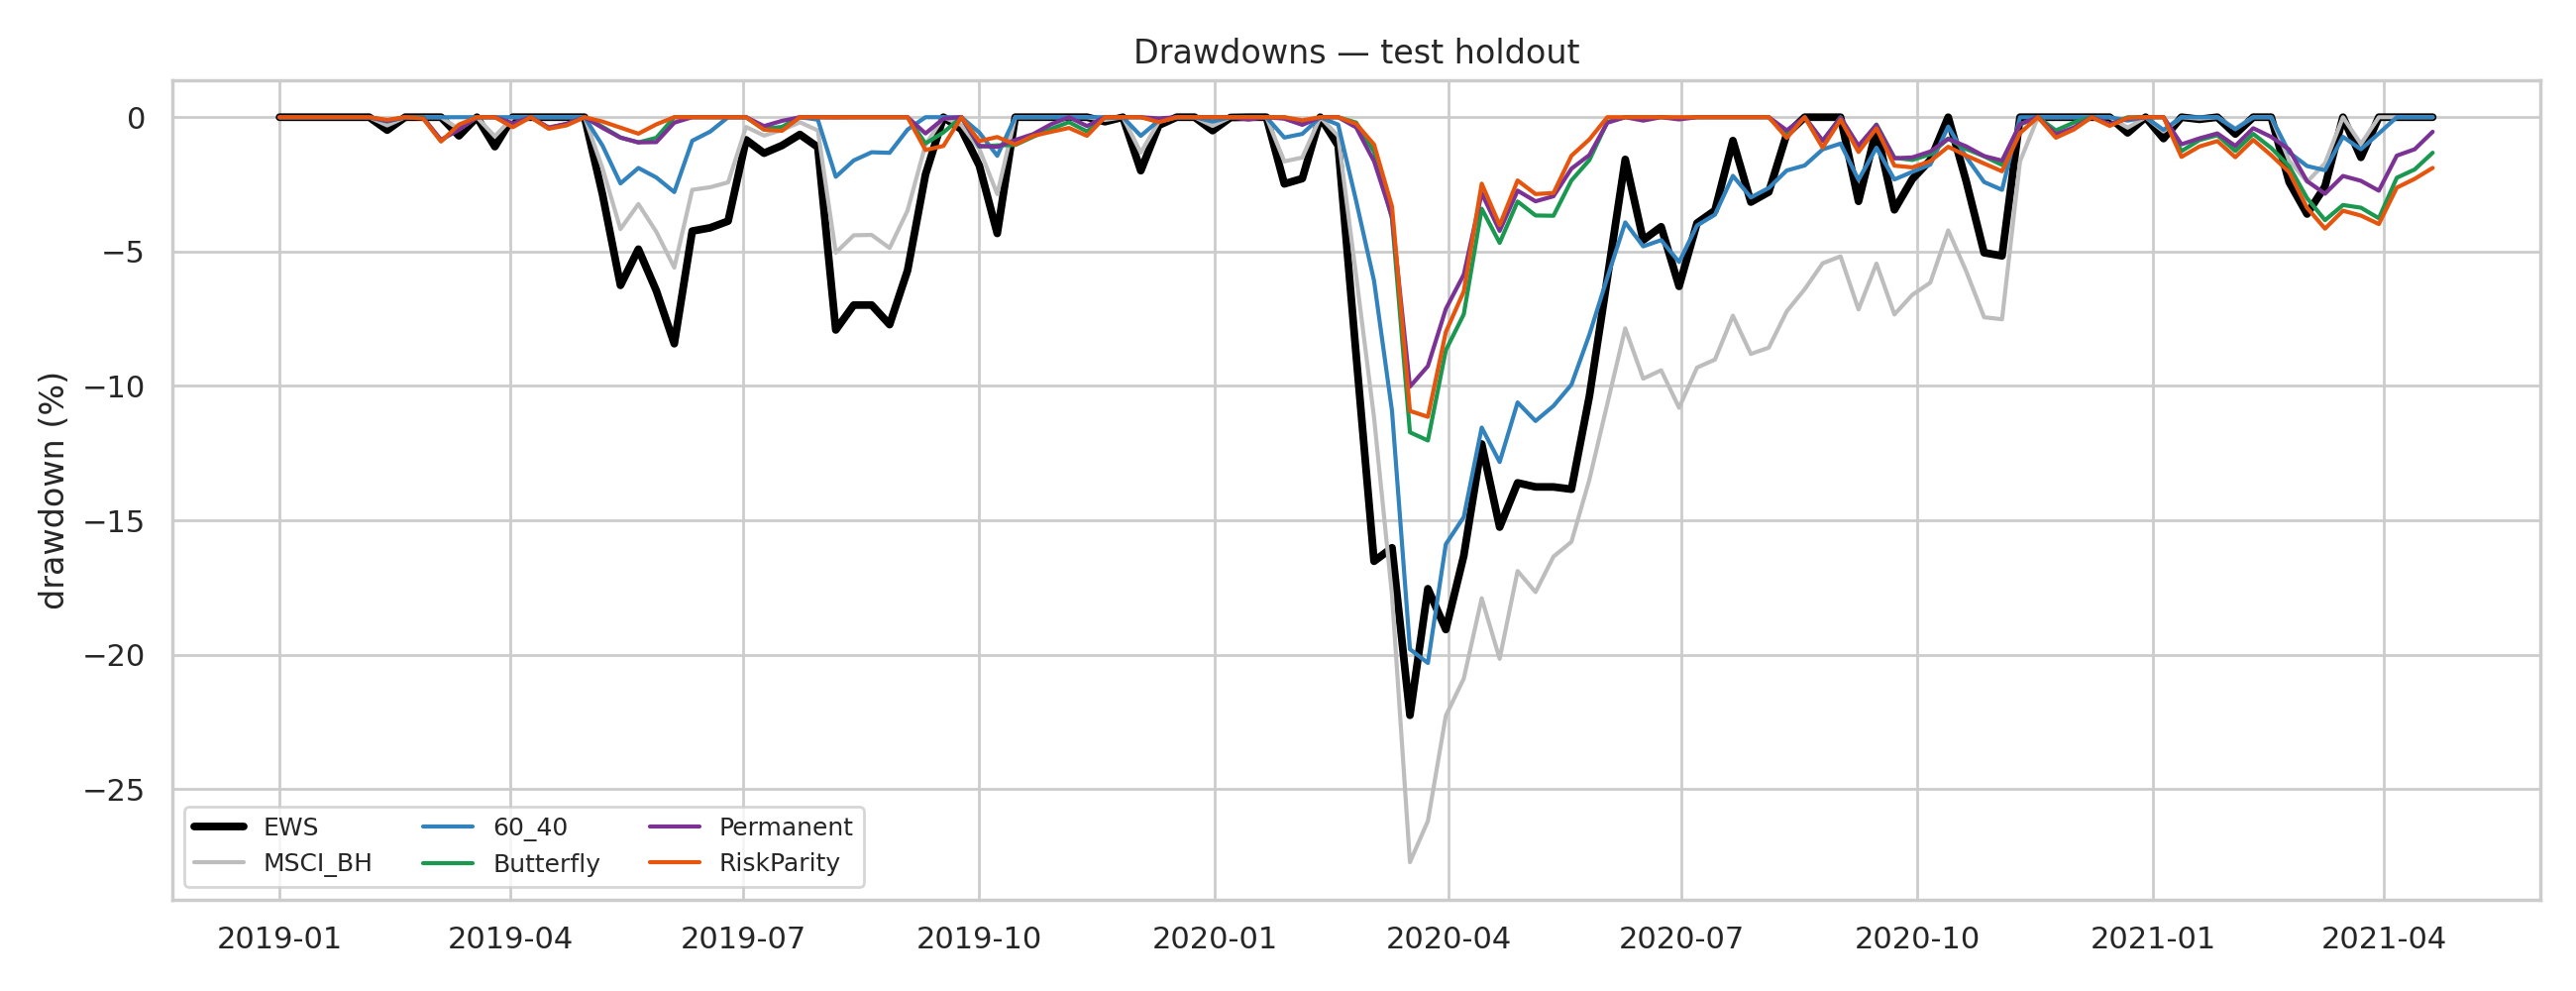

In [21]:
display(Image(filename=str(FIG/'drawdown_curves_all.png')))

## 13. Results: metrics + equity curve + COVID rotation
EWS wins **Sharpe (1.45), Sortino (2.22), Calmar (1.39) and CAGR (0.31)**
across all 6 strategies. MaxDD -0.22 < MSCI -0.28; COVID recovery 22 weeks
vs MSCI 35. The allocation timeline shows the rotation to **GOLD** during
the COVID crash. Honest nuance: always-defensive blends (Permanent / Butterfly
/ Risk Parity) have smaller absolute DDs because they're never fully invested
in equity — but EWS dominates on risk-adjusted return (Quant Strategy, not
Risk Management).

In [22]:
bm = pd.read_csv(TABLES / 'backtest_metrics_all.csv', index_col=0)
bm.loc[['CAGR','Sharpe','Sortino','Calmar','Max_Drawdown','COVID_Crash_DD',
        'COVID_Recovery_Weeks','Tail_Ratio','Annual_Turnover','Hit_Ratio_RiskOff']].round(3)

,EWS,MSCI_BH,60_40,Butterfly,Permanent,RiskParity
CAGR,0.310,0.168,0.137,0.127,0.107,0.124
Sharpe,1.448,0.982,1.100,1.324,1.344,1.315
Sortino,2.223,1.307,1.472,1.797,1.813,1.803
Calmar,1.392,0.606,0.677,1.055,1.070,1.115
Max_Drawdown,-0.223,-0.277,-0.203,-0.120,-0.100,-0.111
COVID_Crash_DD,-0.214,-0.272,-0.201,-0.120,-0.100,-0.111
COVID_Recovery_Weeks,22.000,35.000,33.000,10.000,11.000,10.000
Tail_Ratio,0.972,0.729,0.869,0.961,0.873,0.937
Annual_Turnover,1.289,NaN,NaN,NaN,NaN,NaN
Hit_Ratio_RiskOff,0.478,NaN,NaN,NaN,NaN,NaN


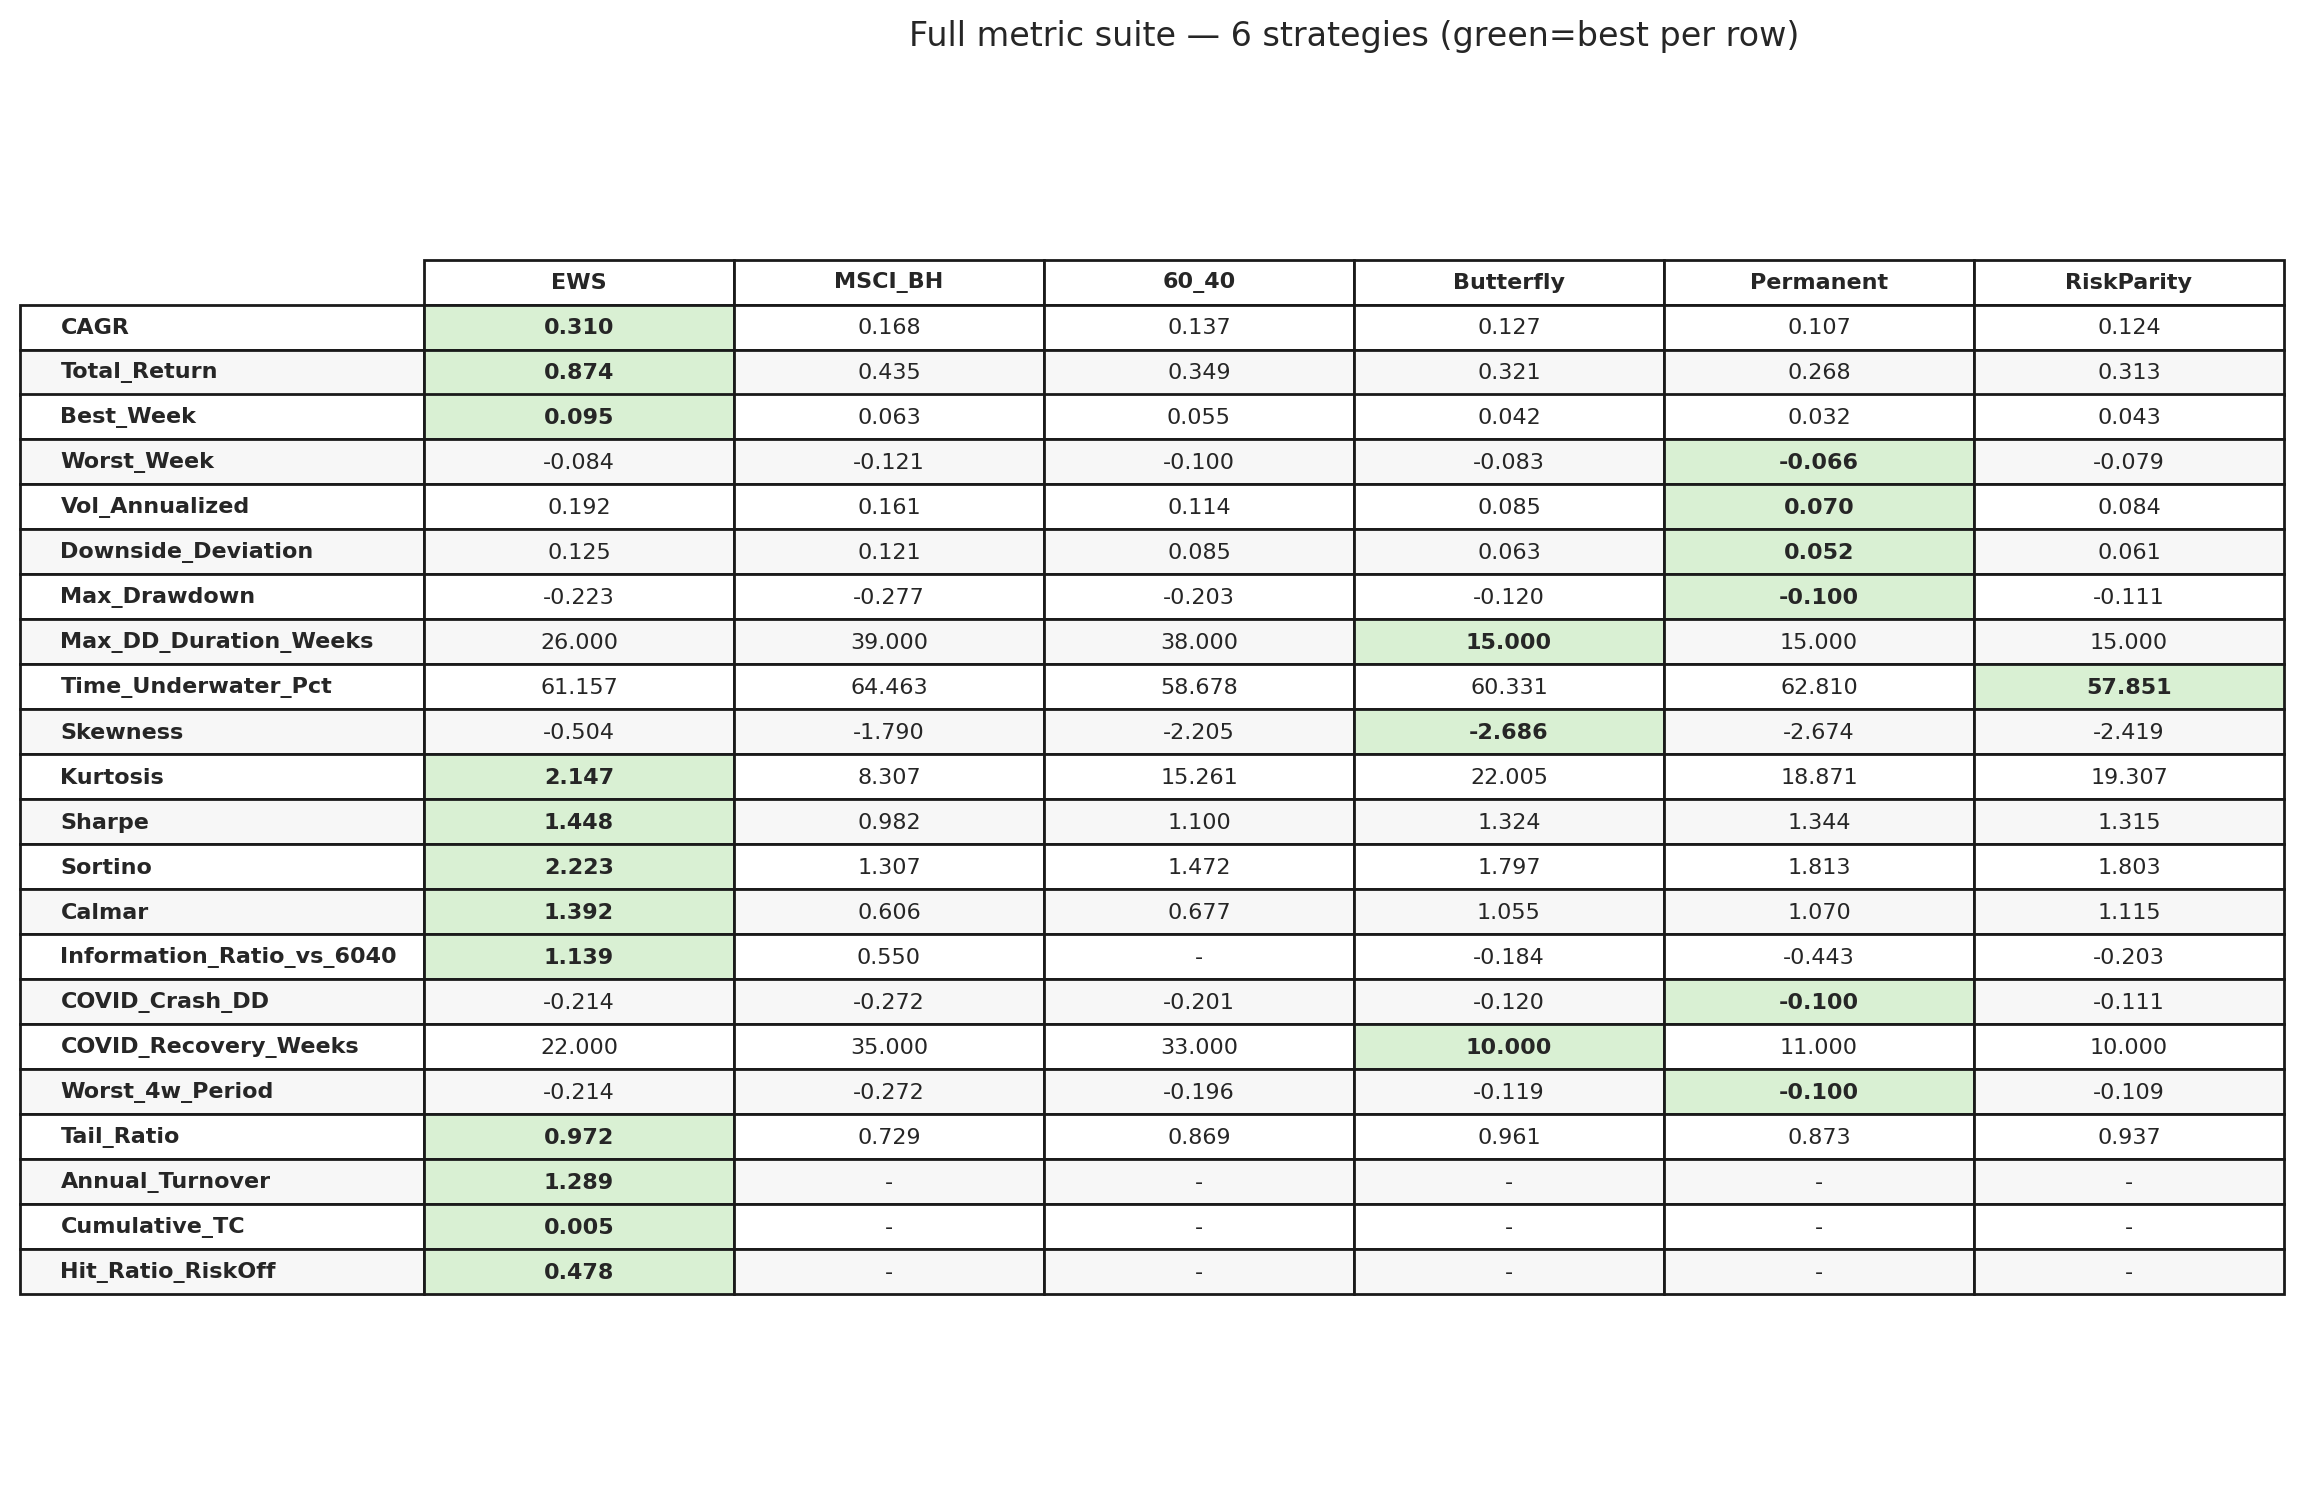

In [23]:
display(Image(filename=str(FIG/'metrics_table.png')))

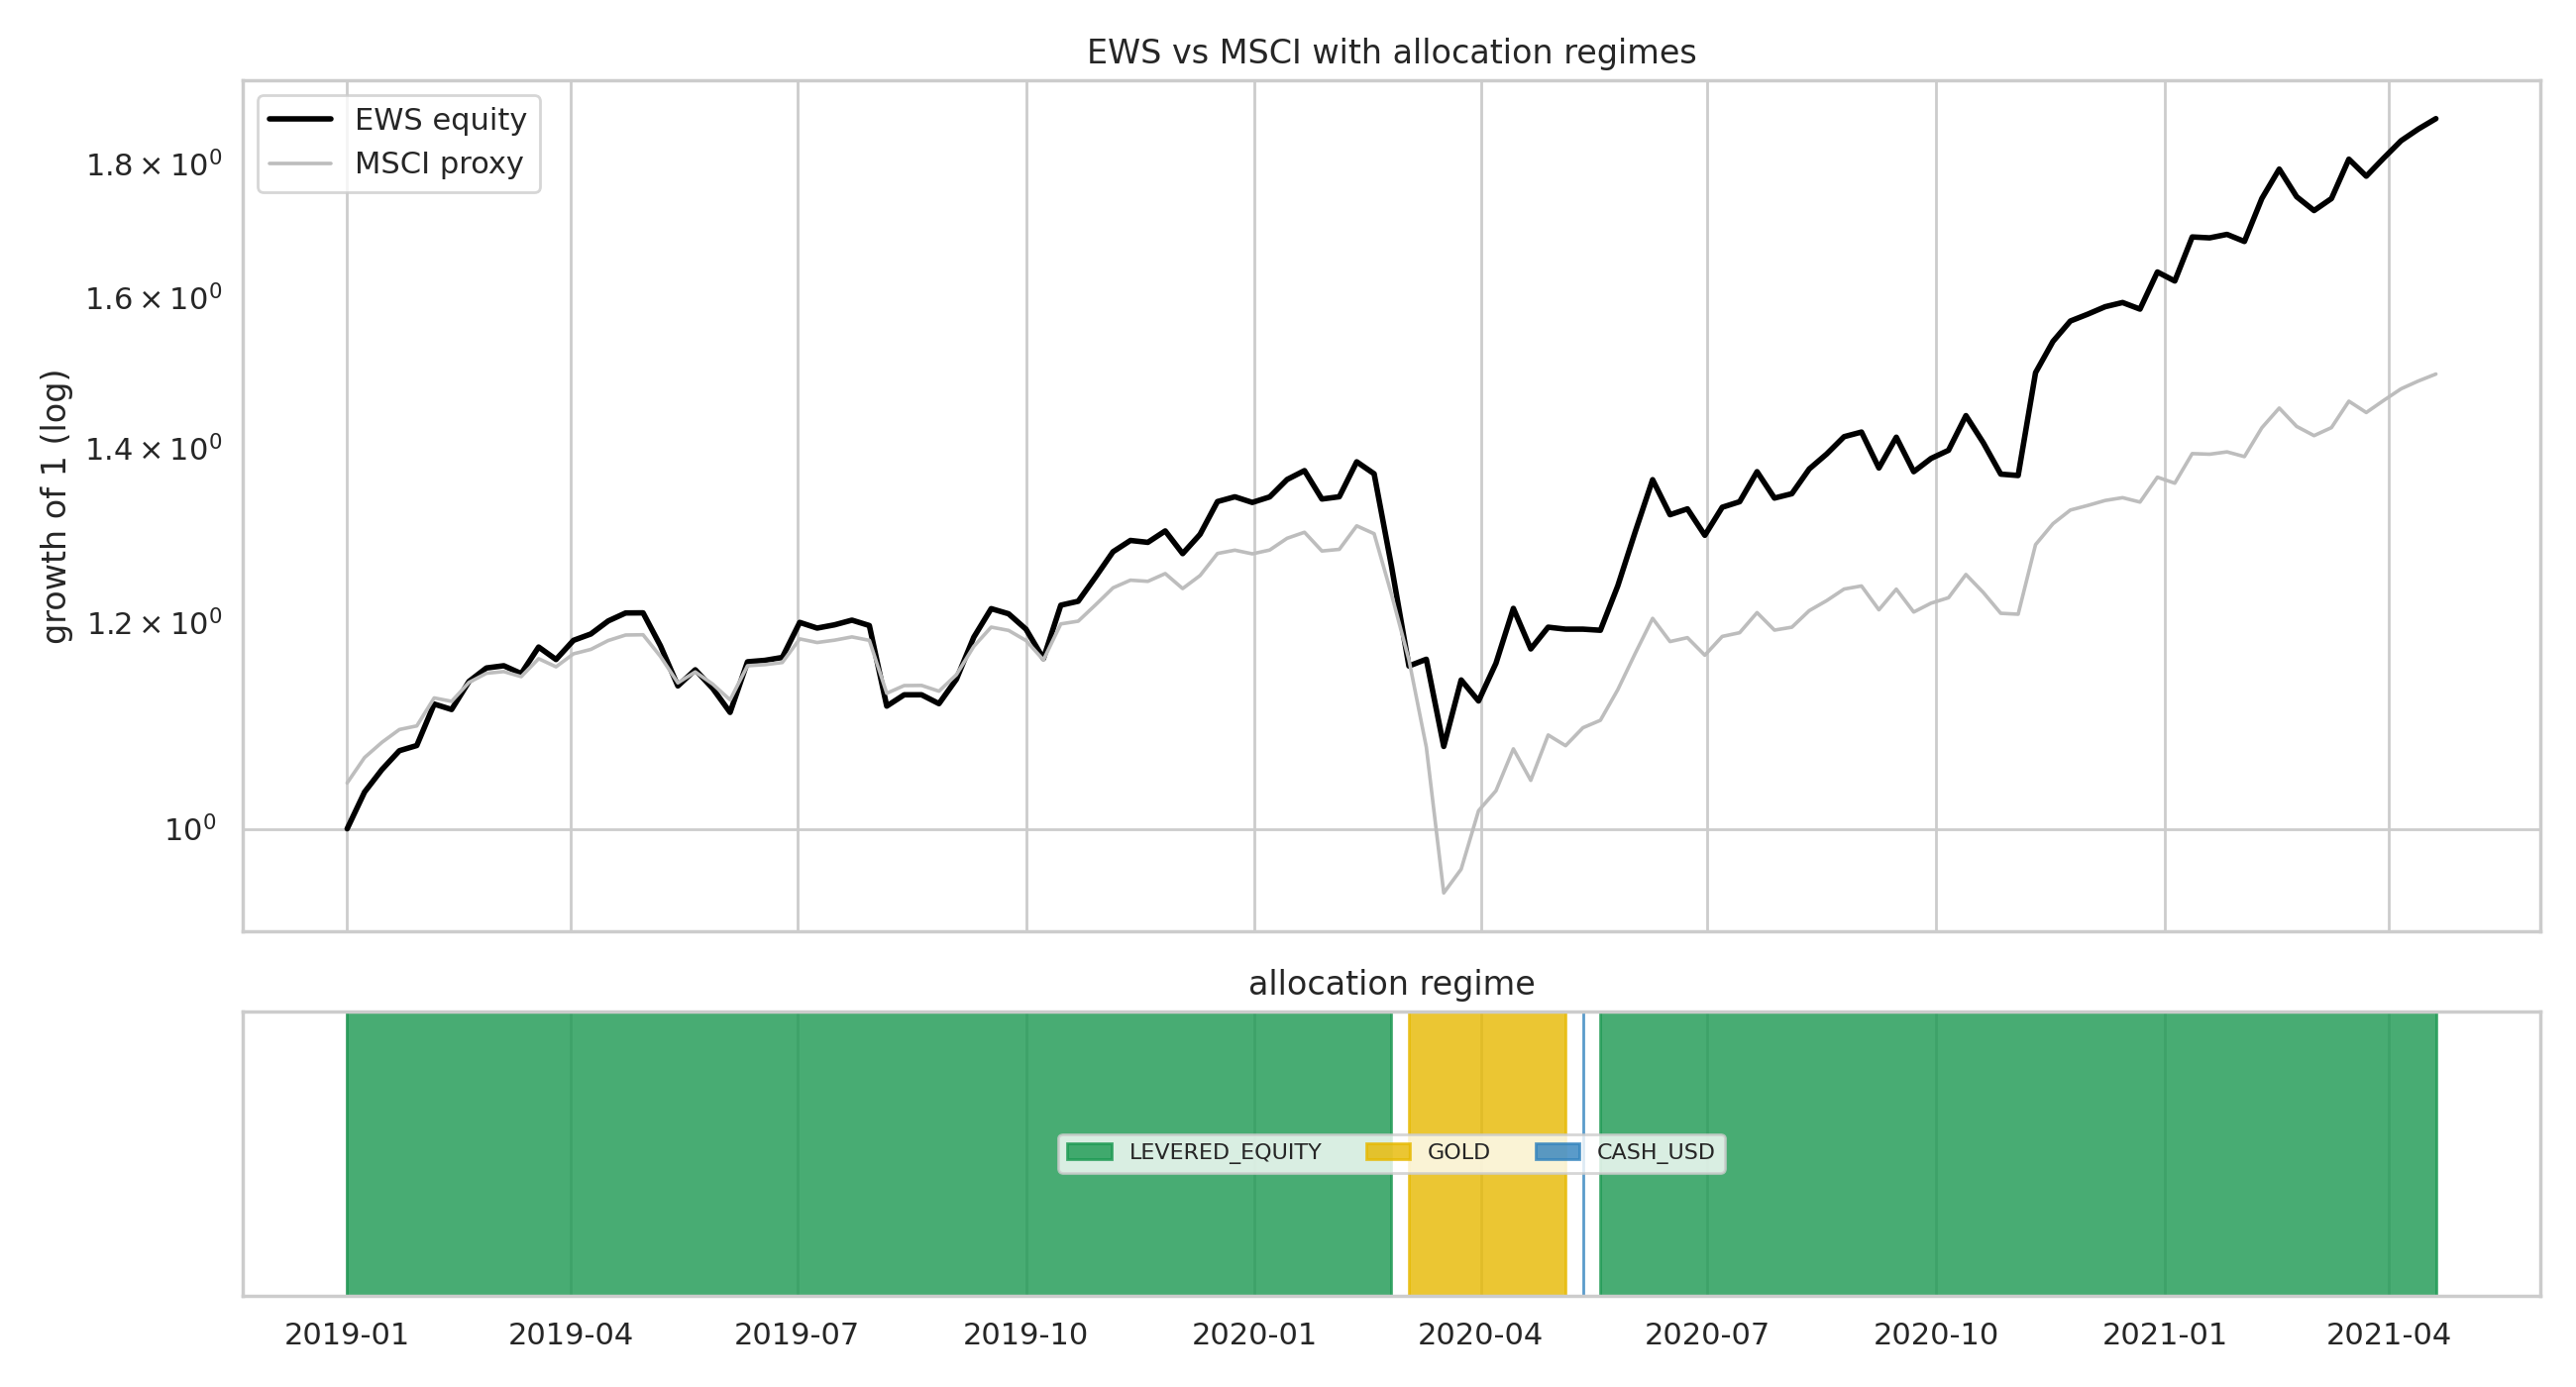

In [24]:
display(Image(filename=str(FIG/'allocation_timeline.png')))

## 14. Conclusions, limitations, future work
**Headline.** Routing the 1.5x leverage with a 4-model ensemble + 3-domain
macro signal beats every static and dynamic benchmark on risk-adjusted return.

**Limitations.** Label sparse post-2013 -> folds 3-5 noisy (mitigated by
n_pos-weighting); training dominated by liquidity / credit crises -> 2022-style
inflation shock untested (data ends Apr-2021); ensemble error correlation 0.507
-> modest boost; MSCI World = equal-weight DM proxy; credit spreads are
log-ratios, not OAS; TC are static estimates; 1-week execution lag is realistic
but costs in fast crashes.

**Future work.** HMM regime switching; ensembles over **disjoint** feature
sets to cut error correlation; daily signals; multi-asset extension; stress
tests on post-2021 inflation/geopolitical shocks; regime-adaptive thresholds.